In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pandas import DataFrame

from caveat.evaluate.describe import transitions as describe_transitions
from caveat.evaluate.describe.frequency import frequency_plots
from caveat.evaluate.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from caveat.evaluate.describe.transitions import sequence_prob_plot
from caveat.evaluate.features import participation, times, transitions

In [50]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_paths = {
    # "Disc RNN": Path("../logs/TRB/discrim"),
    "ContRNNDiscrim": Path("../logs/TRB/conditional"),
    "ContRNNGen": Path("../logs/TRB/vae_labels"),
    # "VAE": Path("../logs/TRB/vae_labels"),
    # "JVAE": Path("../logs/TRB/jvae"),
    "ActVAE": Path("../logs/TRB/cvae"),
    # "SWAE": Path("../logs/TRB/swae"),
    # "CatVAE": Path("../logs/TRB/catvae"),
    # "VQVAE": Path("../logs/TRB/vqvae"),
}

# find data
target_schedules = pd.read_csv("../tmp/nts_schedules_2023.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv("../tmp/nts_attributes_2023.csv")


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }

In [51]:
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(next(best_quality(p, 0))[1], default=target_attributes)
    for n, p in batch_paths.items()
}

Loading synthetic attributes from ../logs/TRB/conditional/conditional_nrun0/version_5
Loading synthetic attributes from ../logs/TRB/vae_labels/vae_labels_nrun0/version_2
Loading synthetic attributes from ../logs/TRB/cvae/cvae_nrun0/version_9


In [52]:
target_attributes.head()

,pid,age,gender,ethnicity,education,license,car_access,work_status,mobility,wheelchair_user,...,income,hh_size,hh_composition,hh_children,hh_cars,hh_bikes,hh_motorcycles,blue_badge,num_license_holders,age_group
0,0,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
1,1,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
2,2,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
3,3,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
4,4,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+


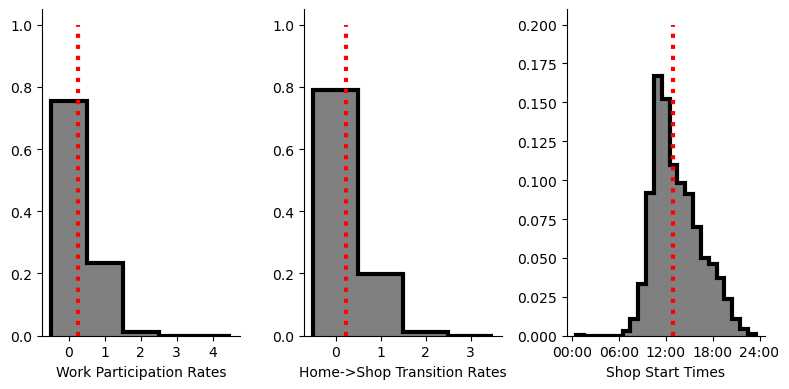

In [5]:
fs = 10
fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=False)

act = "work"
bins, counts = participation.participation_rates_by_act(target_schedules)[act]
expected = np.average(bins, weights=counts) + 0.5
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[0].stairs(counts, bins, lw=3, ec="black", fc="grey", fill=True)
ax[0].vlines(expected, 0, 1, lw=3, ls=":", color="red")

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(ticks, bins)
ax[0].set_xlabel("Work Participation Rates", fontsize=fs)

# =============
bins, counts = transitions.transitions_by_act(target_schedules)["home>shop"]
expected = np.average(bins, weights=counts) + 0.5
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[1].stairs(counts, bins, lw=3, ec="black", fc="grey", fill=True)
ax[1].vlines(expected, 0, 1, lw=3, ls=":", color="red")
bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(ticks, bins)
ax[1].set_xlabel("Home->Shop Transition Rates", fontsize=fs)

# =============

step = 60
act = "shop"
bins, counts = times.start_times_by_act(
    target_schedules, bin_size=step, factor=1
)[act]
expected = np.average(bins, weights=counts) + 0.5
counts = counts / counts.sum()
lookup = dict(zip(bins, counts))

target_bins = pd.Series([i for i in range(0, 1440, step)])
target_bins += step / 2

values = [0] * len(target_bins)

for i, b in enumerate(target_bins):
    values[i] = lookup.get(b, 0)

ax[2].stairs(values[:-1], target_bins, lw=3, fill=True, ec="black", fc="grey")
ax[2].vlines(expected, 0, 0.2, lw=3, ls=":", color="red")
bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[2].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[2].set_xlabel("Shop Start Times", fontsize=fs)

# remove outlines
for i in range(3):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    # ax[i].spines["left"].set_visible(False)
    # ax[i].spines["bottom"].set_visible(False)

fig.tight_layout()

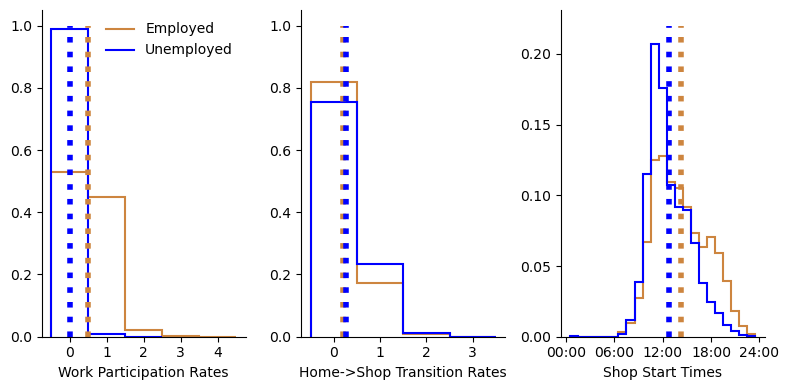

In [6]:
fs = 10
fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=False)
split = split_on(target_schedules, target_attributes, by="work_status")
split = {
    # "Student": split["student"],
    "Employed": split["employed"],
    "Unemployed": split["unemployed"],
}
cmap2 = {"Employed": "peru", "Unemployed": "blue"}

act = "work"

for i, (k, v) in enumerate(split.items()):
    bins, counts = participation.participation_rates_by_act(v)[act]
    expected = np.average(bins, weights=counts) + 0.5
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()

    ax[0].stairs(counts, bins, lw=1.5, label=k, ls="-", color=cmap2[k])
    ax[0].vlines(expected, 0, 1, lw=4, ls=":", color=cmap2[k])

bins, counts = participation.participation_rates_by_act(target_schedules)[act]
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(ticks, bins)
ax[0].set_xlabel(f"{act.title()} Participation Rates", fontsize=fs)

# =============
transition = "home>shop"

for i, (k, v) in enumerate(split.items()):
    bins, counts = transitions.transitions_by_act(v)[transition]
    expected = np.average(bins, weights=counts) + 0.5
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()

    ax[1].stairs(counts, bins, lw=1.5, label=k, ls="-", color=cmap2[k])
    ax[1].vlines(expected, 0, 1, lw=4, ls=":", color=cmap2[k])


bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(ticks, bins)
ax[1].set_xlabel("Home->Shop Transition Rates", fontsize=fs)

# =============

step = 60
act = "shop"

for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    expected = np.average(bins, weights=counts) + step / 2
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for i, b in enumerate(target_bins):
        values[i] = lookup.get(b, 0)

    ax[2].stairs(
        values[:-1], target_bins, lw=1.5, ls="-", label=k, color=cmap2[k]
    )
    ax[2].vlines(expected, 0, 0.22, lw=4, ls=":", color=cmap2[k])

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[2].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[2].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

ax[0].legend(loc="upper right", frameon=False)

# remove outlines
for i in range(3):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.tight_layout()

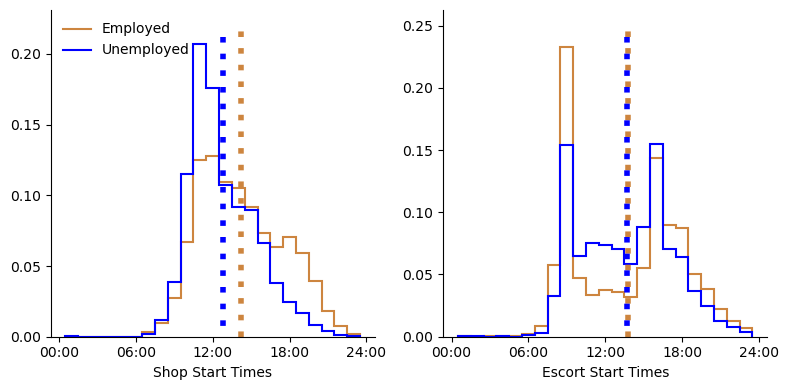

In [7]:
fs = 10
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=False)
split = split_on(target_schedules, target_attributes, by="work_status")
split = {
    # "Student": split["student"],
    "Employed": split["employed"],
    "Unemployed": split["unemployed"],
}
cmap2 = {"Employed": "peru", "Unemployed": "blue"}

step = 60
act = "shop"

for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    expected = np.average(bins, weights=counts) + step / 2
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for j, b in enumerate(target_bins):
        values[j] = lookup.get(b, 0)

    ax[0].stairs(
        values[:-1], target_bins, lw=1.5, ls="-", label=k, color=cmap2[k]
    )
    ax[0].vlines(expected, 0, 0.22, lw=4, ls=(i, (1, 2)), color=cmap2[k])

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[0].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

# =============
step = 60
act = "escort"

for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    expected = np.average(bins, weights=counts) + step / 2
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for j, b in enumerate(target_bins):
        values[j] = lookup.get(b, 0)

    ax[1].stairs(
        values[:-1], target_bins, lw=1.5, ls="-", label=k, color=cmap2[k]
    )
    ax[1].vlines(expected, 0, 0.25, lw=4, ls=(i, (1, 2)), color=cmap2[k])

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[1].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

ax[0].legend(loc="upper left", frameon=False)

# remove outlines
for i in range(2):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.tight_layout()

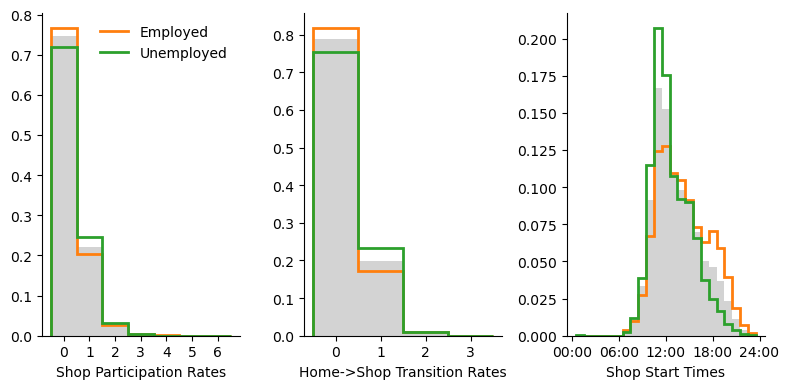

In [8]:
fs = 10
fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=False)
split = split_on(target_schedules, target_attributes, by="work_status")
split = {
    # "Student": split["student"],
    "Employed": split["employed"],
    "Unemployed": split["unemployed"],
}


act = "shop"
bins, counts = participation.participation_rates_by_act(target_schedules)[act]
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[0].stairs(counts, bins, fc="lightgrey", fill=True)

for i, (k, v) in enumerate(split.items()):
    bins, counts = participation.participation_rates_by_act(v)[act]
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()

    ax[0].stairs(counts, bins, lw=2, label=k)

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(ticks, bins)
ax[0].set_xlabel(f"{act.title()} Participation Rates", fontsize=fs)

# =============
transition = "home>shop"
bins, counts = transitions.transitions_by_act(target_schedules)[transition]

minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[1].stairs(counts, bins, fc="lightgrey", fill=True)

for i, (k, v) in enumerate(split.items()):
    bins, counts = transitions.transitions_by_act(v)[transition]
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()
    ax[1].stairs(counts, bins, lw=2, label=k)


bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(ticks, bins)
ax[1].set_xlabel("Home->Shop Transition Rates", fontsize=fs)

# =============

step = 60
bins, counts = times.start_times_by_act(
    target_schedules, bin_size=step, factor=1
)[act]
counts = counts / counts.sum()
lookup = dict(zip(bins, counts))

target_bins = pd.Series([i for i in range(0, 1440, step)])
target_bins += step / 2

values = [0] * len(target_bins)

for i, b in enumerate(target_bins):
    values[i] = lookup.get(b, 0)

ax[2].stairs(values[:-1], target_bins, fill=True, fc="lightgrey")


for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for i, b in enumerate(target_bins):
        values[i] = lookup.get(b, 0)

    ax[2].stairs(values[:-1], target_bins, lw=2, label=k)

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[2].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[2].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

ax[0].legend(loc="upper right", frameon=False)

# remove outlines
for i in range(3):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    # ax[i].spines["left"].set_visible(False)
    # ax[i].spines["bottom"].set_visible(False)

fig.tight_layout()

In [9]:
import ast


# losses
def iter_latest(path: Path):
    for dir in path.iterdir():
        if dir.is_dir():
            yield latest_run(dir)


def latest_run(path: Path):
    dirs = [
        p for p in path.iterdir() if p.is_dir() and p.name.startswith("version")
    ]
    return path.name, sorted(dirs)[-1]


def load_losses(path: Path):
    if not path.exists():
        return None
    with open(path) as f:
        lines = f.readlines()
    return lines


def collect_losses(path: Path):
    losses = load_losses(path)
    if losses is None:
        return None
    train_losses = ast.literal_eval(losses[0][7:])
    test_losses = ast.literal_eval(losses[2][6:])
    return {
        "train_act_recon": train_losses["test_act_recon"]
        / train_losses["test_act_weight"],
        "train_dur_recon": train_losses["test_dur_recon"]
        / train_losses["test_dur_weight"],
        "train_KLD": (
            train_losses["test_KLD"] / train_losses["test_kld_weight"]
            if "test_KLD" in train_losses
            else 0
        ),
        "test_act_recon": test_losses["test_act_recon"]
        / test_losses["test_act_weight"],
        "test_dur_recon": test_losses["test_dur_recon"]
        / test_losses["test_dur_weight"],
        "test_KLD": (
            test_losses["test_KLD"] / test_losses["test_kld_weight"]
            if "test_KLD" in test_losses
            else 0
        ),
    }


collected = pd.DataFrame()
for n, p in batch_paths.items():
    print(n)
    train_nll = []
    train_mse = []
    train_dkl = []
    test_nll = []
    test_mse = []
    test_dkl = []
    for name, m in iter_latest(p):
        loss_path = m / "best_loss.txt"
        losses = collect_losses(loss_path)
        if losses is None:
            continue
        train_nll.append(losses["train_act_recon"])
        train_mse.append(losses["train_dur_recon"])
        train_dkl.append(losses["train_KLD"])
        test_nll.append(losses["test_act_recon"])
        test_mse.append(losses["test_dur_recon"])
        test_dkl.append(losses["test_KLD"])

    train_nll = np.array(train_nll)
    train_mse = np.array(train_mse)
    train_dkl = np.array(train_dkl)
    test_nll = np.array(test_nll)
    test_mse = np.array(test_mse)
    test_dkl = np.array(test_dkl)

    collected[(n, "mean")] = pd.Series(
        {
            "train_nll": train_nll.mean(),
            "train_mse": train_mse.mean(),
            "train_dkl": train_dkl.mean(),
            "test_nll": test_nll.mean(),
            "test_mse": test_mse.mean(),
            "test_dkl": test_dkl.mean(),
        }
    )
    collected[(n, "var")] = pd.Series(
        {
            "train_nll": train_nll.var(),
            "train_mse": train_mse.var(),
            "train_dkl": train_dkl.var(),
            "test_nll": test_nll.var(),
            "test_mse": test_mse.var(),
            "test_dkl": test_dkl.var(),
        }
    )

collected[collected.isnull()] = 0
print(collected.to_latex(float_format="{:.5f}".format))

ContRNNDiscrim
ContRNNGen
ActVAE
\begin{tabular}{lrrrrrr}
\toprule
 & ('ContRNNDiscrim', 'mean') & ('ContRNNDiscrim', 'var') & ('ContRNNGen', 'mean') & ('ContRNNGen', 'var') & ('ActVAE', 'mean') & ('ActVAE', 'var') \\
\midrule
train_nll & 0.04809 & 0.00000 & 0.06100 & 0.00047 & 0.02321 & 0.00000 \\
train_mse & 0.00128 & 0.00000 & 0.00054 & 0.00000 & 0.00014 & 0.00000 \\
train_dkl & 0.00000 & 0.00000 & 7.27984 & 0.63176 & 5.90422 & 0.00000 \\
test_nll & 0.04825 & 0.00000 & 0.06216 & 0.00050 & 0.02374 & 0.00000 \\
test_mse & 0.00129 & 0.00000 & 0.00054 & 0.00000 & 0.00022 & 0.00000 \\
test_dkl & 0.00000 & 0.00000 & 7.29872 & 0.62887 & 5.89426 & 0.00000 \\
\bottomrule
\end{tabular}



In [10]:
collect = pd.DataFrame()
for n, p in batch_paths.items():
    test = []
    gen = []
    for name, m in iter_latest(p):
        loss_path = m / "timer.csv"
        times = pd.read_csv(loss_path, header=None, index_col=0)
        test.append(times.loc["train", 1])
        gen.append(times.loc["generate", 1])
    collect[n] = pd.Series(
        {"test": sum(test) / len(test), "gen": sum(gen) / len(gen)}
    )

collect = collect.T
collect.test = collect.test / 60

print(collect.to_latex(float_format="{:.2f}".format))
collect

\begin{tabular}{lrr}
\toprule
 & test & gen \\
\midrule
ContRNNDiscrim & 2.60 & 3.32 \\
ContRNNGen & 5.17 & 2.16 \\
ActVAE & 7.92 & 1.59 \\
\bottomrule
\end{tabular}



,test,gen
ContRNNDiscrim,2.604732,3.317383
ContRNNGen,5.172456,2.161327
ActVAE,7.921565,1.586799


In [11]:
def build_distance_tables(batch_paths, suffix=""):
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / f"domain_distances{suffix}.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "EMD")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    # distances_combined = distances_combined.set_index(
    #     pd.MultiIndex.from_tuples(distances_combined.index)
    # )

    return distances_combined


order = ["participations", "transitions", "timing", "feasibility", "creativity"]
df = build_distance_tables(batch_paths, suffix="")
print(df.loc[order].to_latex(float_format="{:.3f}".format))

# conditional
df = build_distance_tables(batch_paths, suffix="_subs")
print(df.loc[order].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} \\
 & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.389 & 0.000 & 0.085 & 0.001 & 0.062 & 0.000 \\
transitions & 0.020 & 0.000 & 0.006 & 0.000 & 0.004 & 0.000 \\
timing & 0.169 & 0.000 & 0.034 & 0.000 & 0.027 & 0.000 \\
feasibility & 0.000 & 0.000 & 0.018 & 0.000 & 0.030 & 0.000 \\
creativity & 0.501 & 0.000 & 0.023 & 0.000 & 0.019 & 0.000 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} \\
 & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.395 & 0.000 & 0.102 & 0.001 & 0.072 & 0.000 \\
transitions & 0.023 & 0.000 & 0.009 & 0.000 & 0.005 & 0.000 \\
timing & 0.178 & 0.000 & 0.041 & 0.000 & 0.029 & 0.000 \\
feasibility & 0.000 & 0.000 & 0.018 & 0.000 & 

ContRNNDiscrim               ContRNNGen              ActVAE  \
                          EMD           var        EMD       var       EMD   
domain                                                                       
creativity           0.499468  4.132689e-06   0.014705  0.000022  0.011527   
feasibility          0.000020  2.050519e-09   0.017921  0.000096  0.030284   
participations       0.395019  1.125383e-05   0.102131  0.000523  0.071619   
timing               0.177505  5.202044e-05   0.040856  0.000041  0.029020   
transitions          0.022956  2.304904e-07   0.008862  0.000002  0.005164   

                          
                     var  
domain                    
creativity      0.000001  
feasibility     0.000082  
participations  0.000128  
timing          0.000049  
transitions     0.000002

In [12]:
def group_tables(batch_paths, suffix=""):
    distances_combined = pd.DataFrame()
    descriptions_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / f"group_distances{suffix}.csv"
        ).set_index(["domain", "feature"])
        descriptions = pd.read_csv(
            path / f"group_descriptions{suffix}.csv"
        ).set_index(["domain", "feature"])

        columns = set(distances.columns)
        columns = list(
            columns - set(["observed", "unit", "mean", "std", "sub_pop"])
        )

        print(name, columns)

        distances_combined[(name, "mean")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)
        variances_combined[(name, "std")] = distances[columns].std(axis=1)
        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return (
        distances_combined.loc[index],
        variances_combined,
        descriptions_combined.loc[index],
    )


dist_dist, dist_std, dist_desc = group_tables(batch_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

# conditional
dist_dist, dist_std, dist_desc = group_tables(batch_paths, suffix="_subs")
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

ContRNNDiscrim ['conditional_nrun3', 'conditional_nrun2', 'conditional_nrun0', 'conditional_nrun1', 'conditional_nrun4']
ContRNNGen ['vae_labels_nrun1', 'vae_labels_nrun4', 'vae_labels_nrun2', 'vae_labels_nrun0', 'vae_labels_nrun3']
ActVAE ['cvae_nrun3', 'cvae_nrun1', 'cvae_nrun4', 'cvae_nrun2', 'cvae_nrun0']
\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} \\
 & mean & var & mean & var & mean & var \\
feature &  &  &  &  &  &  \\
\midrule
lengths & 0.954 & 0.000 & 0.199 & 0.006 & 0.145 & 0.001 \\
pair participation rate & 0.017 & 0.000 & 0.006 & 0.000 & 0.005 & 0.000 \\
participation rate & 0.196 & 0.000 & 0.050 & 0.000 & 0.036 & 0.000 \\
2-gram & 0.051 & 0.000 & 0.014 & 0.000 & 0.009 & 0.000 \\
3-gram & 0.006 & 0.000 & 0.003 & 0.000 & 0.002 & 0.000 \\
4-gram & 0.002 & 0.000 & 0.002 & 0.000 & 0.001 & 0.000 \\
durations & 0.099 & 0.000 & 0.022 & 0.000 & 0.019 & 0.000 \\
joint-durations & 0.243 & 0.000 

In [13]:
def build_all_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions.csv").set_index(
            ["domain", "feature", "segment"]
        )
        distances = pd.read_csv(path / "distances.csv").set_index(
            ["domain", "feature", "segment"]
        )
        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )
        descriptions_combined[name, "mean"] = descriptions[columns].mean(axis=1)
        # descriptions_combined[name, "var"] = descriptions[columns].var(axis=1)
        descriptions_combined[name, "EMD"] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["unit"]
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )
    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(
        lambda x: x.sort_values([("Observed", "")], ascending=False).head(20)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables(batch_paths)

p = table.loc["participations"]
for name in ["lengths", "participation rate", "pair participation rate"]:
    print(name)
    print(p.loc[name].to_latex(float_format="{:.3f}".format))
    print()

table.loc["participations"]

lengths
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
sequence lengths & 3.894 & 3.002 & 0.954 & 3.778 & 0.199 & 3.813 & 0.145 & length. \\
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
home & 2.306 & 2.001 & 0.336 & 2.253 & 0.067 & 2.292 & 0.050 & av. rate \\
other & 0.524 & 0.366 & 0.158 & 0.507 & 0.110 & 0.571 & 0.062 & av. rate \\
shop & 0.291 & 0.023 & 0.268 & 0.228 & 0.063 & 0.261 & 0.040 & av. rate \\
work & 0.256 & 0.473 & 0.240 & 0.257 & 0.027 & 0.260 & 0.020 & av. rate \\
escort & 0.256 & 0.004 & 0.252 & 0.259 & 0.0

Observed ContRNNDiscrim  \
                                                                mean   
feature                 segment                                        
lengths                 sequence lengths     3.893647       3.002038   
pair participation rate home+home            1.039079       1.000537   
                        other+other          0.086476       0.000000   
                        home+other           0.084029       0.000000   
                        escort+escort        0.075458       0.000483   
                        home+escort          0.072353       0.000483   
                        shop+shop            0.033325       0.000000   
                        home+shop            0.032701       0.000000   
                        visit+visit          0.013397       0.000000   
                        home+visit           0.013178       0.000000   
                        work+work            0.011221       0.000000   
                        home+work            0.011221       0.000000   
                        other+escort         0.004775       0.000000   
                        other+shop           0.002818       0.000000   
                        escort+shop          0.002160       0.000000   
                        other+visit          0.001873       0.000000   
                        medical+medical      0.001603       0.000000   
                        home+medical         0.001603       0.000000   
                        education+education  0.001164       0.000000   
                        home+education       0.001164       0.000000   
                        visit+shop           0.000945       0.000000   
participation rate      home                 2.306133       2.001100   
                        other                0.523766       0.365609   
                        shop                 0.291167       0.022988   
                        work                 0.256425       0.472555   
                        escort               0.256070       0.004161   
                        visit                0.127647       0.000000   
                        education            0.089581       0.135625   
                        medical              0.042858       0.000000   

                                                      ContRNNGen            \
                                                  EMD       mean       EMD   
feature                 segment                                              
lengths                 sequence lengths     0.953946   3.778392  0.198947   
pair participation rate home+home            0.069771   1.023083  0.024291   
                        other+other          0.086476   0.095274  0.035066   
                        home+other           0.084029   0.093566  0.034037   
                        escort+escort        0.074975   0.052858  0.022600   
                        home+escort          0.071870   0.051325  0.021028   
                        shop+shop            0.033325   0.020231  0.013094   
                        home+shop            0.032701   0.019938  0.012763   
                        visit+visit          0.013397   0.006058  0.007347   
                        home+visit           0.013178   0.005983  0.007208   
                        work+work            0.011221   0.010434  0.003837   
                        home+work            0.011221   0.010407  0.003844   
                        other+escort         0.004775   0.000854  0.003921   
                        other+shop           0.002818   0.000479  0.002339   
                        escort+shop          0.002160   0.000024  0.002136   
                        other+visit          0.001873   0.000439  0.001434   
                        medical+medical      0.001603   0.000442  0.001384   
                        home+medical         0.001603   0.000442  0.001384   
                        education+education  0.001164   0.001620  0.001373   
                        

In [14]:
def distance_weighted_av(
    report: DataFrame,
    base_col: str = "observed__weight",
    suffix: str = "__weight",
):
    """Weighted average of dataframe using weights in the weight column and a base column.
    This deals with cases where models have different features.
    """
    cols = list(report.columns)
    cols = [c for c in cols if not c.endswith(suffix)]
    base_weights = report[base_col]
    scores = DataFrame()
    for c in cols:
        weights = report[f"{c}{suffix}"]
        weights = (weights + base_weights) / 2
        total = weights.sum()
        scores[c] = report[c] * weights / total
    return scores.sum()


def build_labels_table(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        label_distances = pd.read_csv(
            path / "label_distances_subs.csv"
        ).set_index(["domain", "feature", "segment", "label"])

        columns = set(label_distances.columns)
        # unit = label_distances["unit"].groupby(["domain", "label"]).first()

        columns = list(
            columns
            - set(
                [
                    # "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                    "cat",
                    "label",
                    "domain",
                    "feature",
                    "segment",
                ]
            )
        )
        label_distances = (
            label_distances[columns]
            .groupby(["domain", "label"])
            .apply(distance_weighted_av)
        )

        descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)
        descriptions_combined[name, "var"] = label_distances.var(axis=1)

    # descriptions_combined["Description", ""] = unit
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    order = list(descriptions_combined.columns)

    index = ["participations", "transitions", "timing"]

    return descriptions_combined.loc[index, order]


table = build_labels_table(batch_paths)
print(table.to_latex(float_format="{:.3f}".format))


table

\begin{tabular}{llrrrrrr}
\toprule
 &  & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} \\
 &  & EMD & var & EMD & var & EMD & var \\
domain & label &  &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{participations} & age_group & 0.116 & 0.002 & 0.061 & 0.005 & 0.050 & 0.006 \\
 & car_access & 0.101 & 0.003 & 0.052 & 0.006 & 0.047 & 0.006 \\
 & gender & 0.101 & 0.003 & 0.050 & 0.006 & 0.046 & 0.006 \\
 & income & 0.102 & 0.003 & 0.050 & 0.006 & 0.046 & 0.006 \\
 & work_status & 0.109 & 0.002 & 0.056 & 0.005 & 0.046 & 0.006 \\
\cline{1-8}
\multirow[t]{5}{*}{transitions} & age_group & 0.014 & 0.000 & 0.009 & 0.000 & 0.006 & 0.000 \\
 & car_access & 0.008 & 0.000 & 0.004 & 0.000 & 0.003 & 0.000 \\
 & gender & 0.008 & 0.000 & 0.004 & 0.000 & 0.003 & 0.000 \\
 & income & 0.011 & 0.000 & 0.005 & 0.000 & 0.004 & 0.000 \\
 & work_status & 0.011 & 0.000 & 0.006 & 0.000 & 0.004 & 0.000 \\
\cline{1-8}
\multirow[t]{5}{*}{timing} & age_group & 0.227 &

/tmp/ipykernel_3603315/2783010140.py:25: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(


ContRNNDiscrim               ContRNNGen            \
                                      EMD           var        EMD       var   
domain         label                                                           
participations age_group         0.116128  2.125108e-03   0.061109  0.005325   
               car_access        0.101147  2.659725e-03   0.051617  0.005746   
               gender            0.100615  2.680891e-03   0.049522  0.005900   
               income            0.101939  2.614749e-03   0.050369  0.005835   
               work_status       0.108962  2.282733e-03   0.055554  0.005453   
transitions    age_group         0.013734  1.763519e-06   0.008817  0.000003   
               car_access        0.007613  8.206759e-07   0.004086  0.000002   
               gender            0.008231  4.193357e-07   0.004314  0.000003   
               income            0.010533  7.224821e-07   0.005409  0.000004   
               work_status       0.010755  1.719823e-06   0.006204  0.000002   
timing         age_group         0.227416  1.211085e-02   0.116539  0.026985   
               car_access        0.215779  1.348297e-02   0.104436  0.028978   
               gender            0.213010  1.372578e-02   0.103177  0.029194   
               income            0.216767  1.327262e-02   0.104894  0.028904   
               work_status       0.219603  1.295914e-02   0.110581  0.027954   

                              ActVAE            
                                 EMD       var  
domain         label                            
participations age_group    0.049922  0.006161  
               car_access   0.047404  0.006066  
               gender       0.046010  0.006171  
               income       0.046456  0.006136  
               work_status  0.046474  0.006136  
transitions    age_group    0.005927  0.000008  
               car_access   0.003264  0.000003  
               gender       0.003406  0.000004  
               income       0.004324  0.000006  
               work_status  0.003993  0.000005  
timing         age_group    0.100898  0.029572  
               car_access   0.097992  0.030068  
               gender       0.097245  0.030195  
               income       0.098007  0.030064  
               work_status  0.098207  0.030031

In [15]:
def build_all_description_tables_subs_fixed(batch_paths, on="work_status"):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
        label_distances = pd.read_csv(path / "label_distances_subs.csv")

        descriptions = pd.read_csv(path / "descriptions_subs.csv")

        columns = set(label_descriptions.columns)
        columns = list(
            columns
            - set(
                [
                    "label",
                    "cat",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
        )

        distances = (
            label_distances[columns]
            .loc[label_distances.label == on]
            .set_index(["domain", "feature", "segment"])
            .groupby(["domain", "feature", "segment"])
            .apply(distance_weighted_av)
        ).reset_index()
        descriptions["label"] = on
        distances["label"] = on
        descriptions["cat"] = "combined"
        distances["cat"] = "combined"

        columns = set(distances.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )
        distances = distances[columns]

        label_descriptions = pd.concat((label_descriptions, descriptions))
        label_distances = pd.concat((label_distances, distances))

        label_descriptions = (
            label_descriptions.loc[label_descriptions.label == on]
            .drop("label", axis=1)
            .set_index(["domain", "feature", "segment", "cat"])
        )
        label_distances = (
            label_distances.loc[label_distances.label == on]
            .drop("label", axis=1)
            .set_index(["domain", "feature", "segment", "cat"])
        )

        columns = set(label_descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )

        observed = label_descriptions["observed"]
        unit = label_descriptions["unit"]

        label_descriptions = label_descriptions[columns]
        label_distances = label_distances[columns]

        descriptions_combined[name, "mean"] = label_descriptions.mean(axis=1)
        descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)

    descriptions_combined["Observed", ""] = observed
    descriptions_combined["Description", ""] = unit
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )
    descriptions_combined["maxi"] = descriptions_combined.Observed.groupby(
        ["domain", "feature", "segment"], group_keys=False
    ).transform("max")
    descriptions_combined = descriptions_combined.sort_values(
        ["maxi"], ascending=False
    ).drop(columns=["maxi"])

    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(lambda x: x.head(1000))

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables_subs_fixed(batch_paths)

p = table.loc["participations"]
for name in ["lengths", "participation rate"]:
    print(name)
    pp = p.loc[name]
    pp.loc[:, "Description"] = "rate"
    print(pp.to_latex(float_format="{:.3f}".format))
    print()

/tmp/ipykernel_3603315/3814685357.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_3603315/3814685357.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")


lengths
\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{sequence lengths} & employed & 3.979 & 3.000 & 1.042 & 3.776 & 0.244 & 3.869 & 0.163 & rate \\
 & combined & 3.894 & 3.002 & 0.954 & 3.778 & 0.211 & 3.813 & 0.152 & rate \\
 & unemployed & 3.823 & 3.003 & 0.880 & 3.781 & 0.168 & 3.762 & 0.138 & rate \\
 & student & 3.475 & 3.018 & 0.545 & 3.781 & 0.338 & 3.615 & 0.191 & rate \\
\cline{1-10}
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{home} & unemployed & 2.2

/tmp/ipykernel_3603315/3814685357.py:106: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).drop(columns=["maxi"])


In [16]:
table = build_all_description_tables_subs_fixed(batch_paths, on="gender")
t = table.loc["transitions"]
acts = [
    "home>other",
    "home>work",
    "home>education",
    "home>shop",
    "home>visit",
    "home>escort",
    "home>medical",
]
data = []
for act in acts:
    tt = t.loc["2-gram"]
    tt.loc[:, "Description"] = "rate"
    tt = tt.loc[([act]),]
    data.append(tt)
data = pd.concat(data)
data = data.sort_index(ascending=False)
print(data.to_latex(float_format="{:.3f}".format))
data

/tmp/ipykernel_3603315/3814685357.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_3603315/3814685357.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")


\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{home>work} & combined & 0.243 & 0.542 & 0.247 & 0.220 & 0.034 & 0.241 & 0.016 & rate \\
 & M & 0.263 & 0.493 & 0.243 & 0.220 & 0.043 & 0.253 & 0.019 & rate \\
 & F & 0.216 & 0.454 & 0.251 & 0.220 & 0.025 & 0.226 & 0.014 & rate \\
\cline{1-10}
\multirow[t]{3}{*}{home>visit} & combined & 0.095 & 0.000 & 0.095 & 0.098 & 0.021 & 0.087 & 0.018 & rate \\
 & M & 0.086 & 0.000 & 0.086 & 0.099 & 0.021 & 0.082 & 0.020 & rate \\
 & F & 0.103 & 0.000 & 0.103 & 0.097 & 0.021 & 0.093 & 0.016 & rate \\
\cline{1-10}
\multirow[t]{3}{*}{home>shop} & combined & 0.221 & 0.030 & 0.198 & 0.167 & 0.054 & 0.187 & 0.039 & rate \\
 & M & 0.213 & 0.013 & 0.200 & 0.166 & 0.047 & 0.179 & 0.039 & rate \\
 & F & 0.228 & 0.032 & 0.19

/tmp/ipykernel_3603315/3814685357.py:106: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).drop(columns=["maxi"])


Observed ContRNNDiscrim           ContRNNGen  \
                                            mean       EMD       mean   
segment        cat                                                      
home>work      combined  0.243422       0.541887  0.247230   0.220047   
               M         0.262795       0.493032  0.242603   0.219965   
               F         0.216067       0.453665  0.251497   0.220122   
home>visit     combined  0.094805       0.000000  0.094805   0.098146   
               M         0.086347       0.000000  0.086347   0.098869   
               F         0.102599       0.000000  0.102599   0.097478   
home>shop      combined  0.221097       0.029804  0.198102   0.166660   
               M         0.213117       0.012699  0.200418   0.166492   
               F         0.228451       0.032485  0.195966   0.166815   
home>other     combined  0.450335       0.372610  0.094578   0.415471   
               M         0.459721       0.360392  0.099329   0.414154   
               F         0.441685       0.370427  0.090197   0.416687   
home>medical   combined  0.037582       0.000000  0.037572   0.053133   
               M         0.033417       0.000000  0.033417   0.052748   
               F         0.041402       0.000000  0.041402   0.053487   
home>escort    combined  0.198197       0.005913  0.196204   0.215787   
               M         0.179950       0.000042  0.179908   0.216062   
               F         0.215013       0.007962  0.207051   0.215533   
home>education combined  0.086337       0.159115  0.050592   0.084981   
               M         0.086347       0.133835  0.048989   0.084930   
               F         0.086328       0.137278  0.052070   0.085028   

                                     ActVAE           Description  
                              EMD      mean       EMD              
segment        cat                                                 
home>work      combined  0.033759  0.241198  0.016312        rate  
               M         0.043280  0.252792  0.019234        rate  
               F         0.024979  0.225674  0.013616        rate  
home>visit     combined  0.021205  0.087446  0.018262        rate  
               M         0.021416  0.081641  0.020227        rate  
               F         0.021012  0.092807  0.016448        rate  
home>shop      combined  0.054450  0.186701  0.039218        rate  
               M         0.046625  0.179299  0.038674        rate  
               F         0.061665  0.193536  0.039719        rate  
home>other     combined  0.102118  0.486343  0.045665        rate  
               M         0.105759  0.498300  0.047684        rate  
               F         0.098762  0.475303  0.043803        rate  
home>medical   combined  0.017863  0.031275  0.010376        rate  
               M         0.020290  0.027413  0.009293        rate  
               F         0.015626  0.034829  0.011375        rate  
home>escort    combined  0.055759  0.177367  0.031861        rate  
               M         0.055702  0.169440  0.024262        rate  
               F         0.055813  0.184670  0.038871        rate  
home>education combined  0.017017  0.065593  0.022083        rate  
               M         0.017393  0.066228  0.020716        rate  
               F         0.016671  0.064035  0.023344        rate

In [17]:
table = build_all_description_tables_subs_fixed(batch_paths, on="car_access")
t = table.loc["timing"]
acts = ["work0", "education0", "shop0", "home0", "visit0", "home1"]
data = []
for act in acts:
    tt = t.loc["start times"]
    tt.loc[:, "Description"] = "days"
    tt = tt.loc[([act]),]
    data.append(tt)
data = pd.concat(data)
data = data.sort_index(ascending=False)
print(data.to_latex(float_format="{:.3f}".format))

data = []
for act in acts:
    tt = t.loc["durations"]
    tt.loc[:, "Description"] = "days"
    tt = tt.loc[([act]),]
    data.append(tt)
data = pd.concat(data)
data = data.sort_index(ascending=False)
print(data.to_latex(float_format="{:.3f}".format))

/tmp/ipykernel_3603315/3814685357.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_3603315/3814685357.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")


\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{ContRNNDiscrim} & \multicolumn{2}{r}{ContRNNGen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{work0} & yes & 0.362 & 0.510 & 0.159 & 0.385 & 0.033 & 0.384 & 0.024 & days \\
 & unknown & 0.347 & 0.457 & 0.131 & 0.399 & 0.071 & 0.402 & 0.068 & days \\
 & no & 0.382 & 0.473 & 0.114 & 0.385 & 0.023 & 0.414 & 0.033 & days \\
 & combined & 0.365 & 0.506 & 0.155 & 0.385 & 0.031 & 0.387 & 0.025 & days \\
\cline{1-10}
\multirow[t]{4}{*}{visit0} & yes & 0.562 & 0.000 & 0.562 & 0.570 & 0.019 & 0.565 & 0.020 & days \\
 & unknown & 0.641 & 0.000 & 0.641 & 0.584 & 0.104 & 0.519 & 0.158 & days \\
 & no & 0.553 & 0.000 & 0.553 & 0.570 & 0.024 & 0.565 & 0.018 & days \\
 & combined & 0.562 & 0.000 & 0.562 & 0.570 & 0.020 & 0.565 & 0.020 & days \\
\cline{1-10}
\multirow[t]{4}{*}{shop0} & yes & 0.532 & 0.335 & 0.2

/tmp/ipykernel_3603315/3814685357.py:106: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).drop(columns=["maxi"])


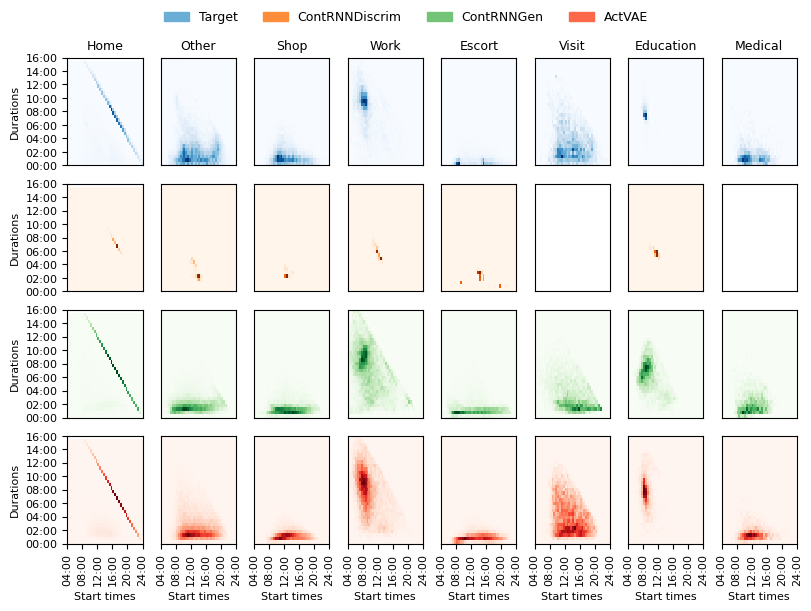

In [18]:
fig = joint_time_distributions_plot(
    target_schedules,
    schedules,
    figsize=(8, 6),
    observed_title="Target",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)

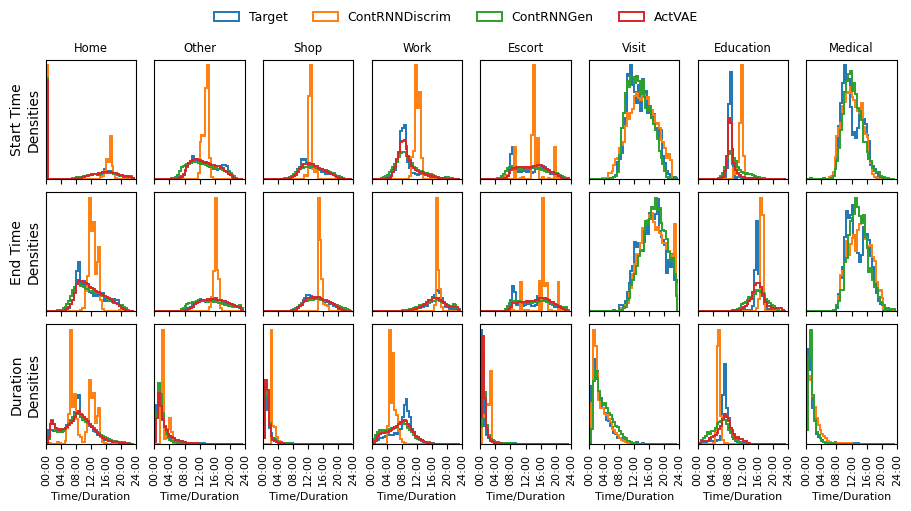

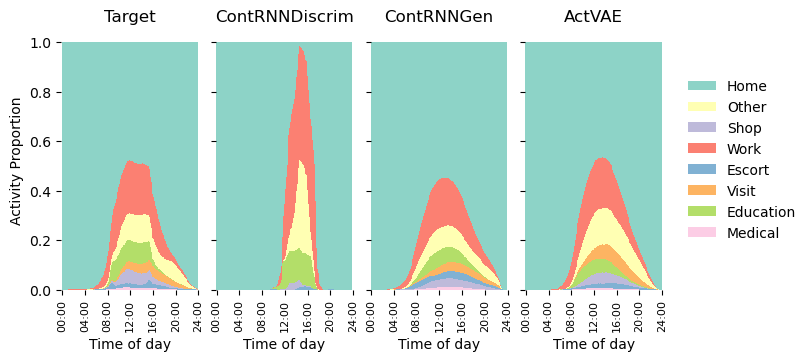

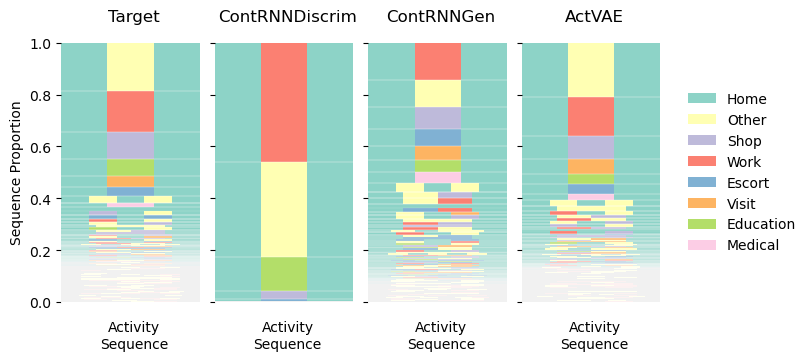

In [19]:
fig = times_distributions_plot(
    target_schedules, schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    schedules,
    color=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    target_schedules,
    schedules,
    cmap=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)

In [20]:
import random

from pam.core import Household, Person
from pam.plot.plans import plot_household

from caveat.data.utils import trace_to_pam


def stretch(schedules):
    return schedules.groupby(schedules.pid).apply(stretcher)


def stretcher(schedule):
    duration = schedule.duration.sum()
    if duration != 1440:
        a = 1440 / duration
        schedule.duration = (schedule.duration * a).astype(int)
        accumulated = list(schedule.duration.cumsum())
        schedule.start = [0] + accumulated[:-1]
        schedule.end = accumulated
    return schedule


def trim(schedules):
    schedules[schedules.end > 1440] = 1440
    schedules[schedules.start > 1440] = 1440
    schedules.duration = schedules.end - schedules.start
    schedules = schedules[schedules.duration > 0]
    return schedules


def pad(schedules):
    return (
        schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
    )


def padder(schedule):
    if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
        pid = schedule.pid.iloc[0]
        schedule = pd.concat(
            [
                schedule,
                DataFrame(
                    {
                        "pid": pid,
                        "start": schedule.end.iloc[-1],
                        "end": 1440,
                        "duration": 1440 - schedule.end.iloc[-1],
                        "act": "home",
                    },
                    index=[0],
                ),
            ]
        )
    elif schedule.end.iloc[-1] < 1440:
        schedule.end.iloc[-1] = 1440
        schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
    return schedule


def plot_schedules(schedules, **kwargs):
    cmap = {
        "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
        "other": (1.0, 1.0, 0.7019607843137254),
        "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
        "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
        "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
        "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
        "education": (
            0.7019607843137254,
            0.8705882352941177,
            0.4117647058823529,
        ),
        "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
        "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
    }
    cmap = {n.title(): c for n, c in cmap.items()}

    hh = Household("")
    pids = schedules.pid
    selected = random.sample(list(pids), 8)
    for i, pid in enumerate(selected):
        person = Person(pid)
        plan = schedules[schedules.pid == pid]
        plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
        mapping = {a: a for a in plan.act}

        trace = [
            (row.act, row.start, row.end, row.duration)
            for i, row in plan.iterrows()
        ]
        plan = trace_to_pam(trace, mapping)

        person = Person(i)
        person.plan = plan
        hh.add(person)

    plot_household(hh, cmap=cmap, width=25)

/tmp/ipykernel_3603315/3145219427.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_3603315/3145219427.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_3603315/3145219427.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the groupi

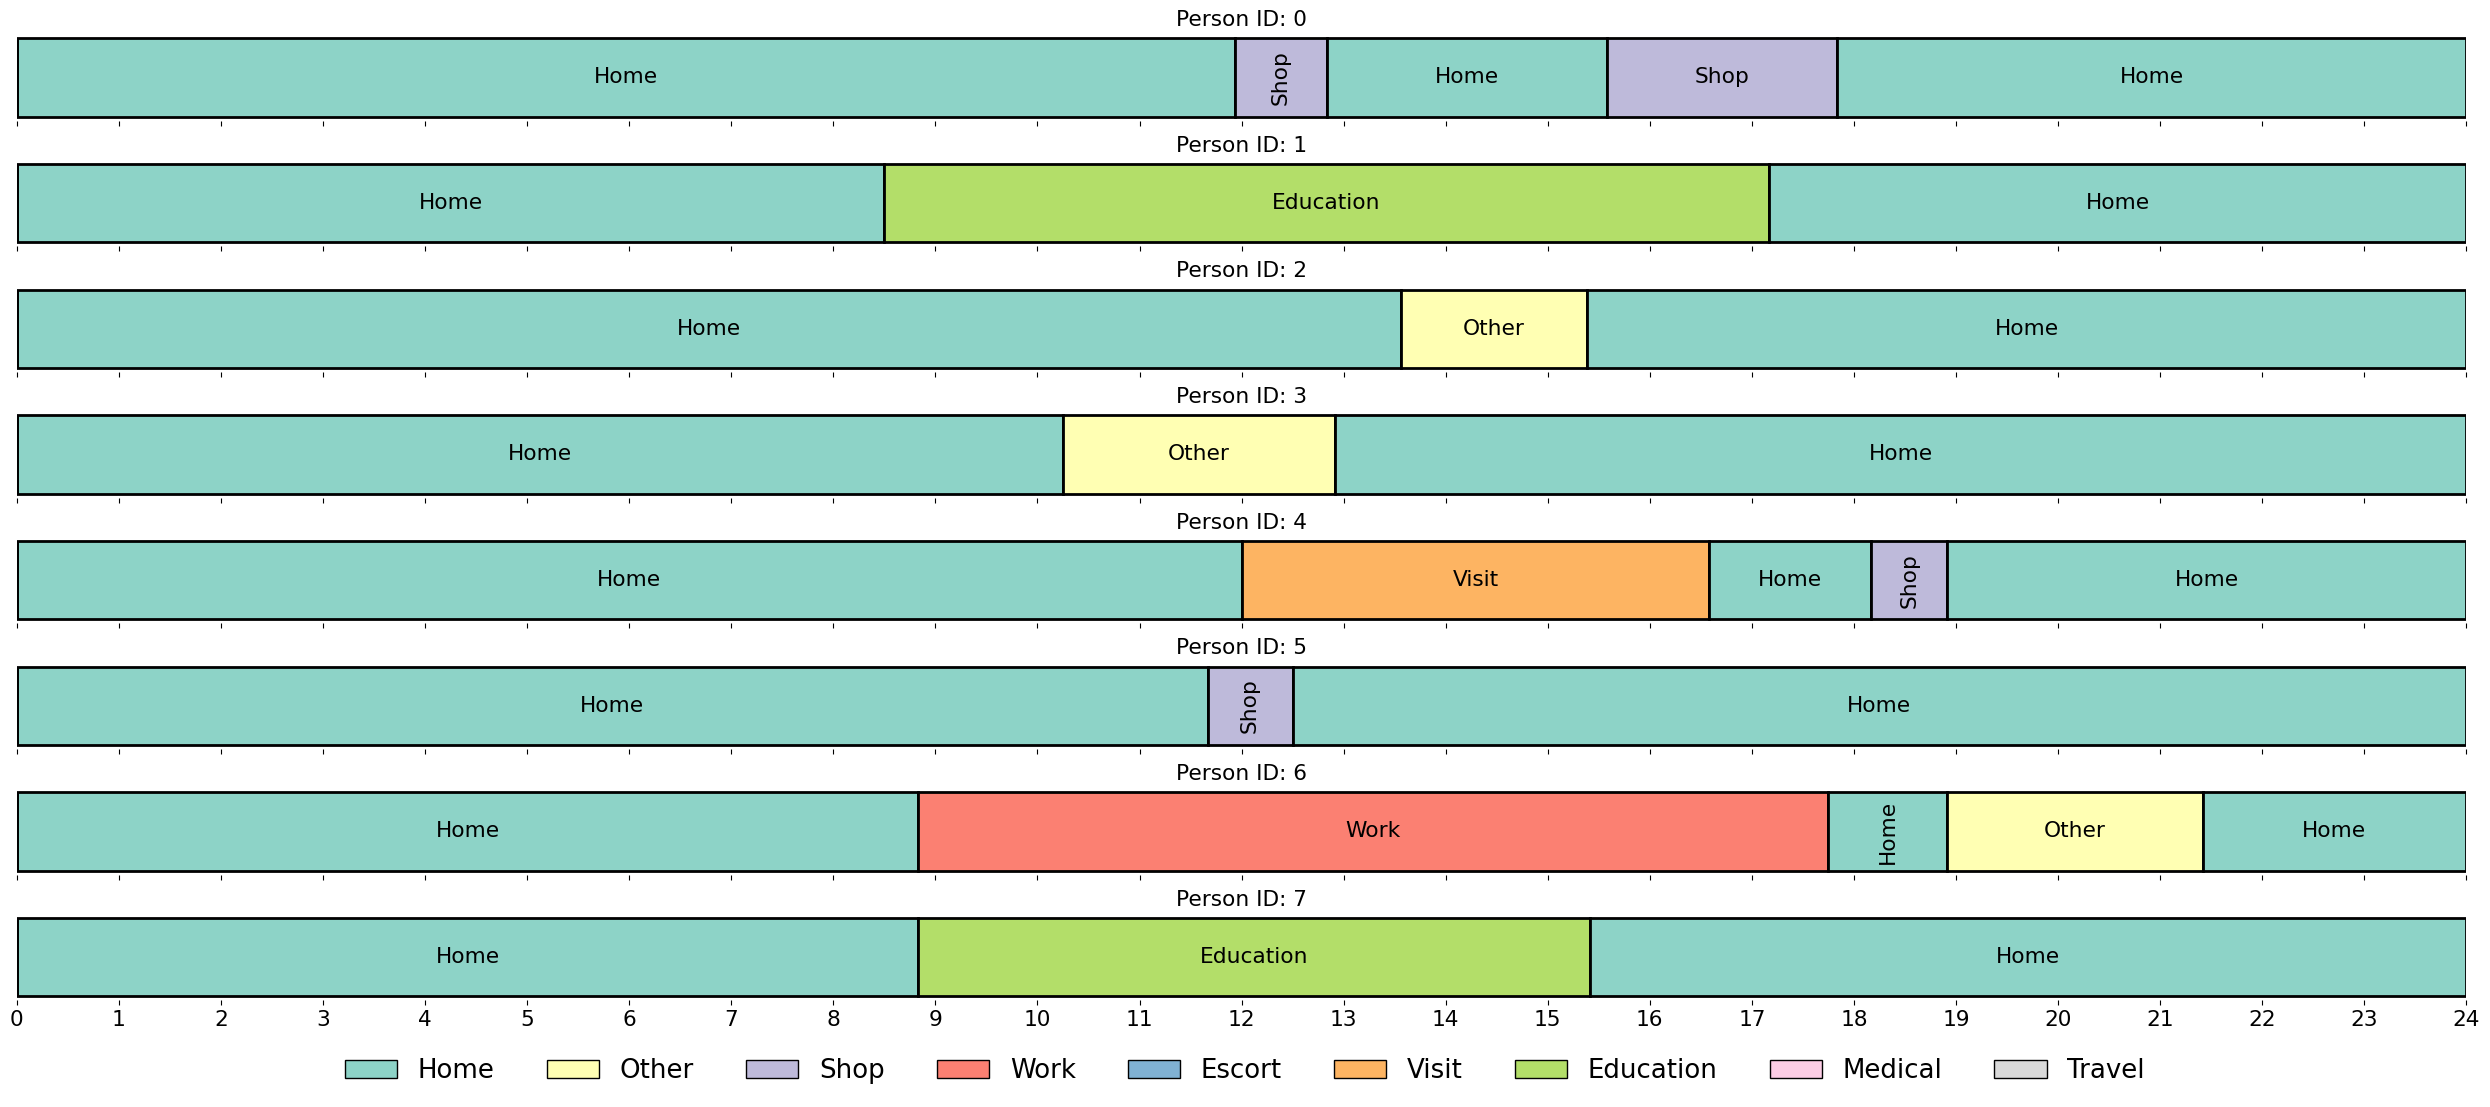

In [21]:
plot_schedules(target_schedules)

/tmp/ipykernel_3603315/3145219427.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_3603315/3145219427.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_3603315/3145219427.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the groupi

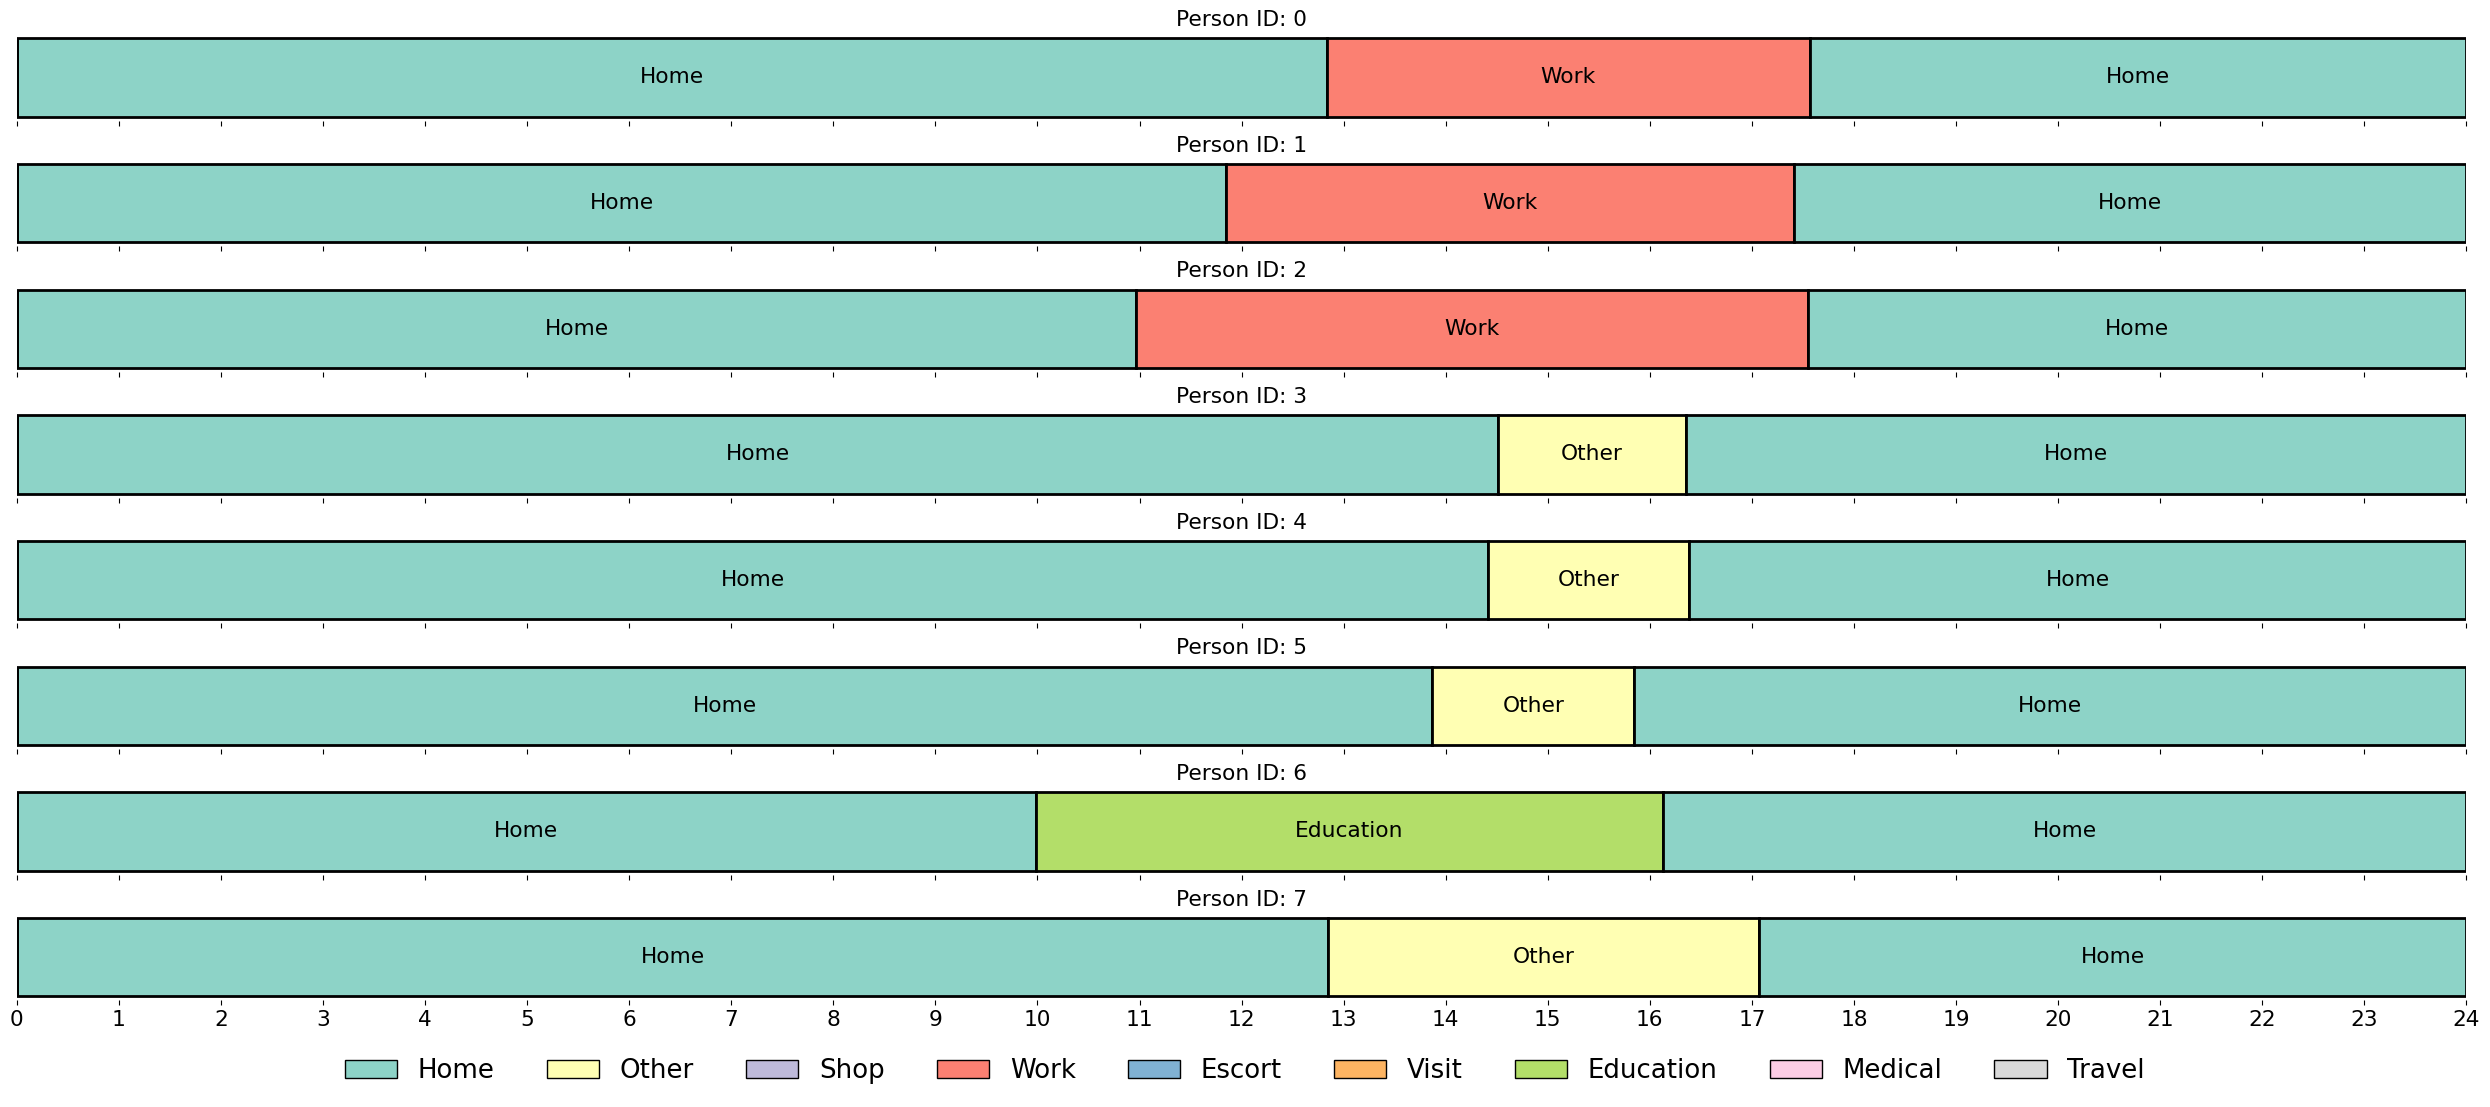

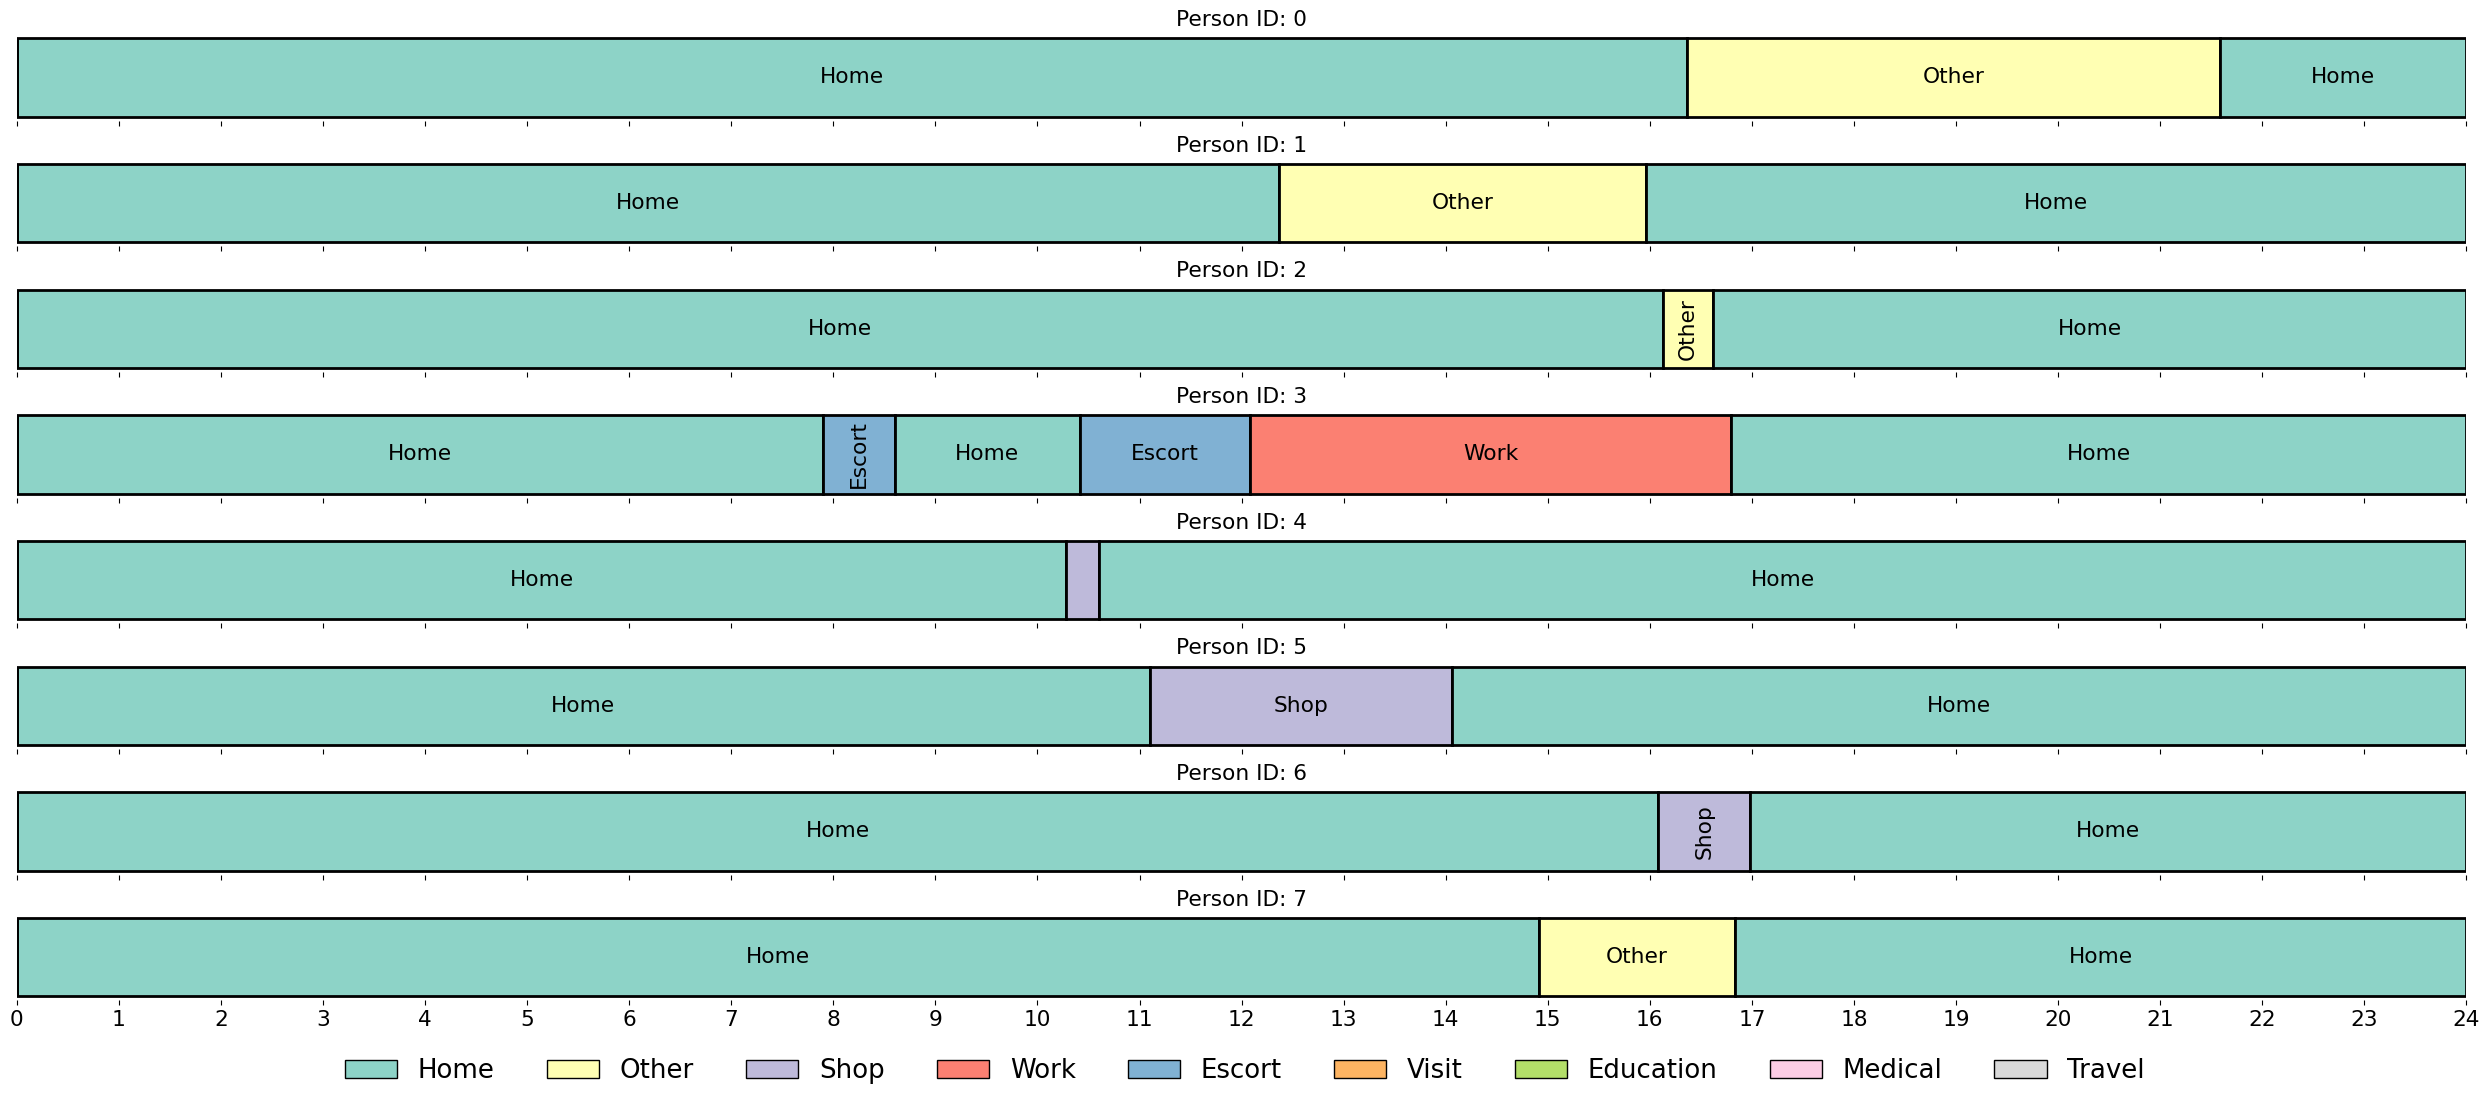

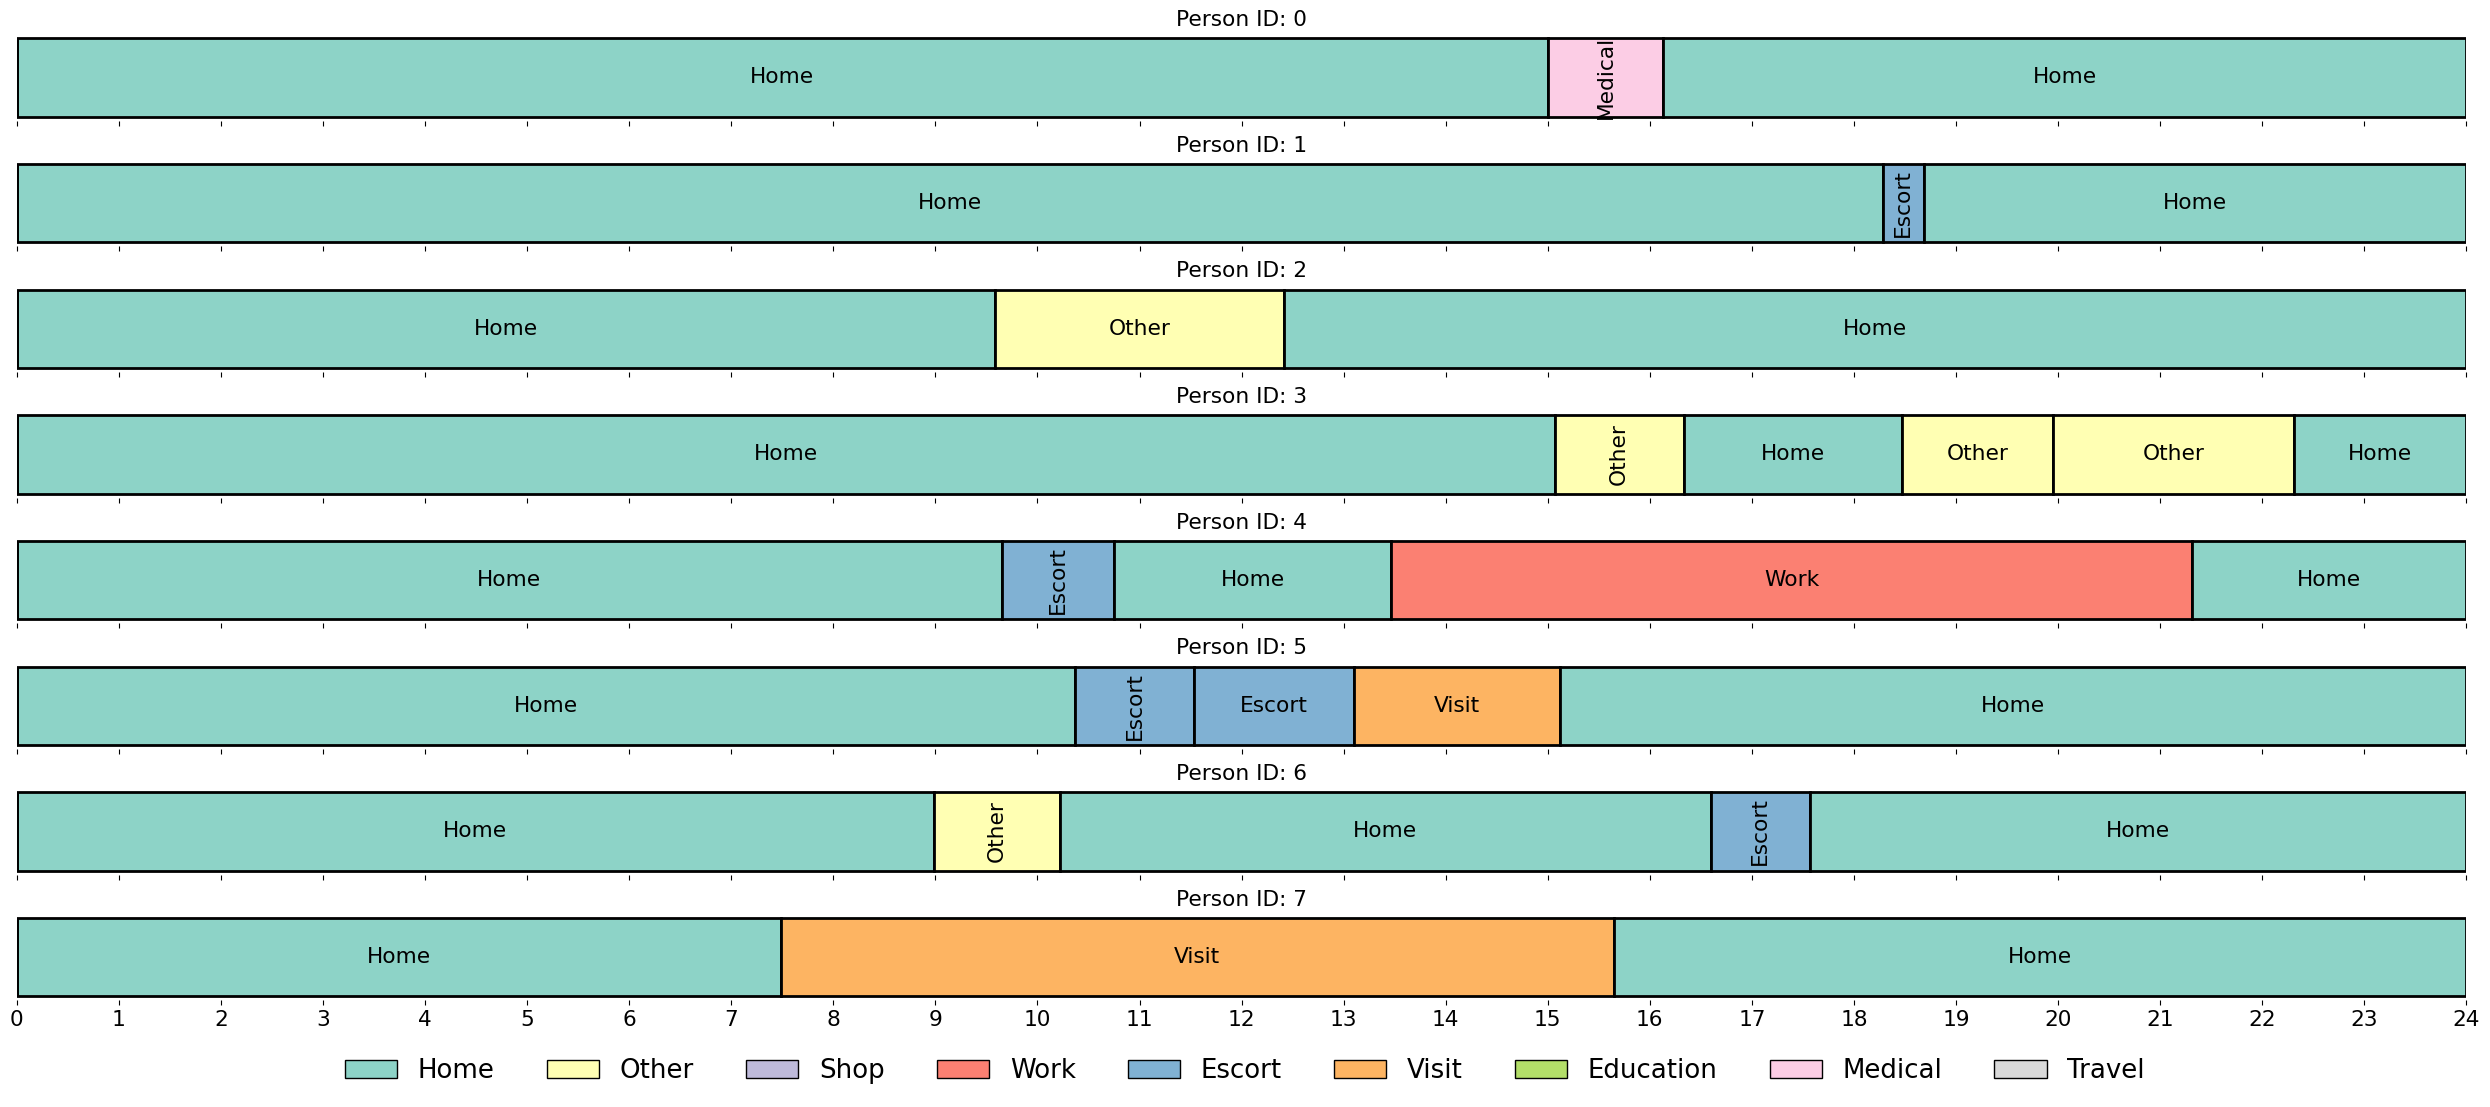

In [22]:
for n, p in batch_paths.items():
    examples = pd.read_csv(next(find_nth(p))[1] / "synthetic_schedules.csv")
    plot_schedules(examples)

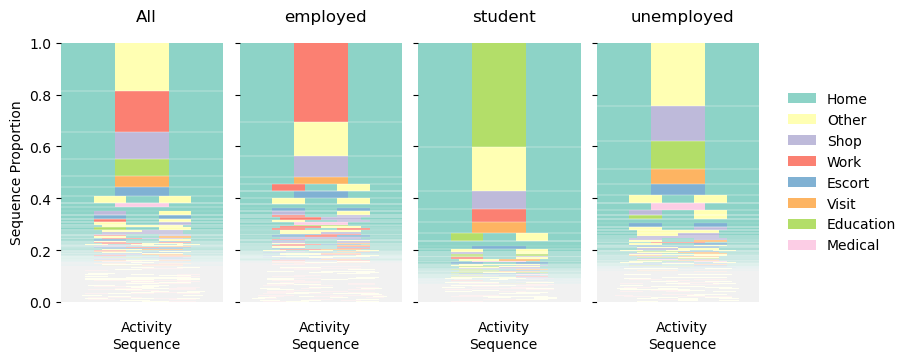

In [23]:
splits = split_on(target_schedules, target_attributes)
fig = describe_transitions.sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
)

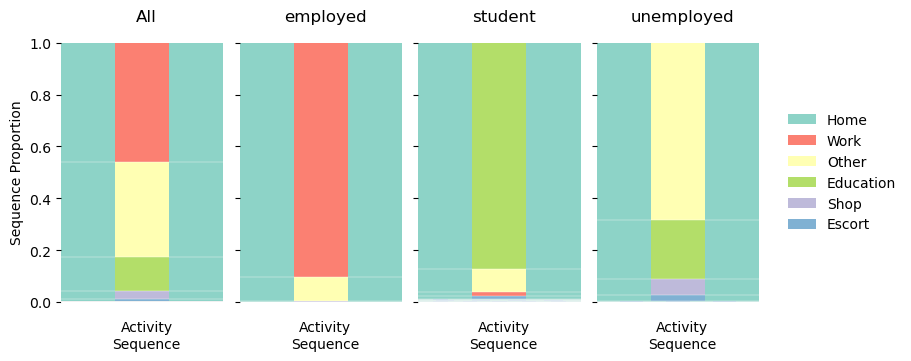

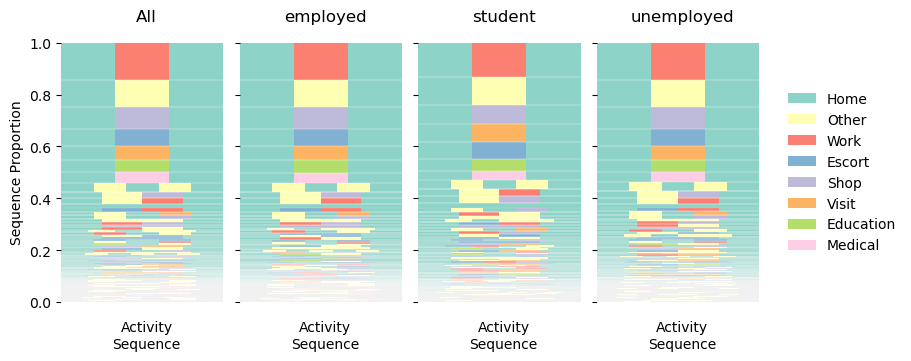

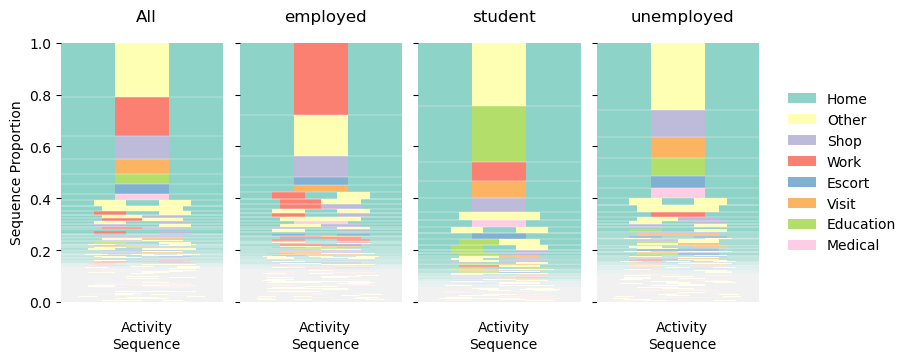

In [24]:
for k, scheds in schedules.items():
    splits = split_on(scheds, attributes[k])
    fig = describe_transitions.sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
    )

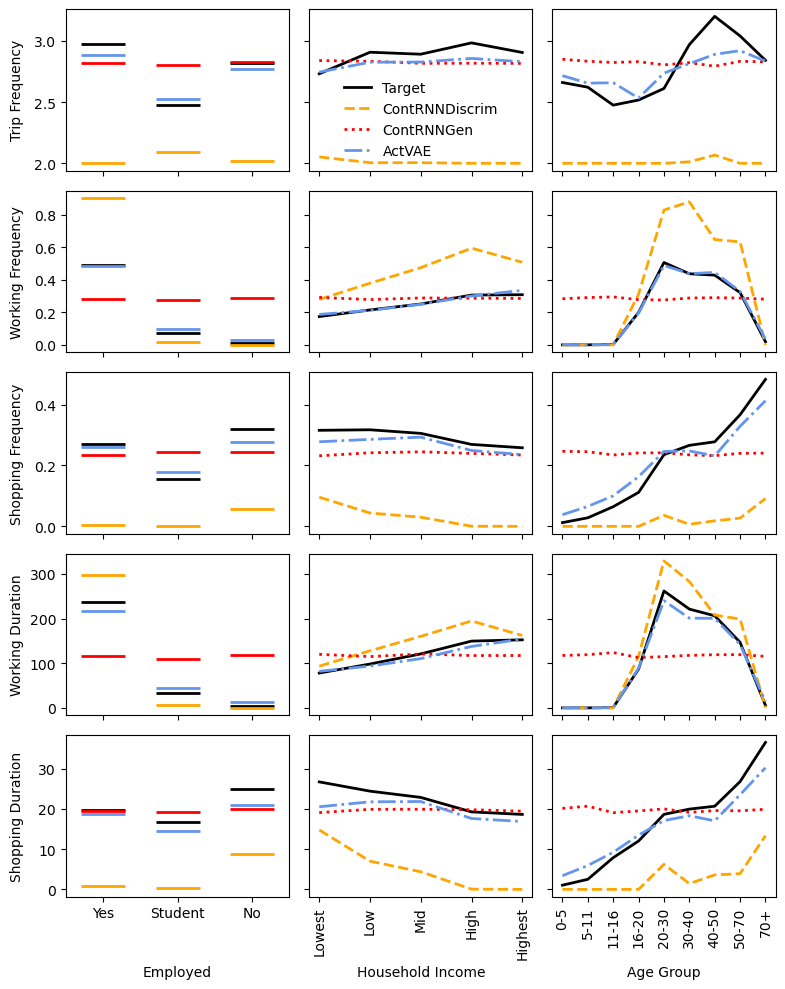

In [74]:
def duration(schedules, act="work"):
    n = schedules.pid.nunique()
    return schedules[schedules.act == act].duration.sum() / n


def count_trips(schedules):
    n = schedules.pid.nunique()
    return (len(schedules) - n) / n


def count_acts(schedules, act="work"):
    n = schedules.pid.nunique()
    return len(schedules.loc[schedules.act == act]) / n


def plot_conditionals(
    schedules, attributes, target_schedules, target_attributes, figsize=(8, 10)
):
    age_order = [
        "<5",
        "5-11",
        "11-16",
        "16-20",
        "20-30",
        "30-40",
        "40-50",
        "50-70",
        "70+",
    ]
    ages = [
        "0-5",
        "5-11",
        "11-16",
        "16-20",
        "20-30",
        "30-40",
        "40-50",
        "50-70",
        "70+",
    ]
    colours = [
        "black",
        "orange",
        "red",
        "cornflowerblue",
        "purple",
        "grey",
        "black",
        "lightgrey",
        "pink",
        "green",
    ]
    styles = ["-", "--", ":", "-.", ":", ".-"]

    fig, axs = plt.subplots(5, 3, figsize=figsize, sharex="col", sharey="row")

    # ==============================
    # trips employment
    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][0]
    # change to bar plot
    for n, col in zip(df.columns, colours):
        ax.scatter(
            df.index, df[n], label=n, color=col, lw=2, marker="_", s=1000
        )
    ax.set_ylabel("Trip Frequency")
    ax.legend().remove()

    # ==============================
    # trips income
    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ==================================
    # trips age group
    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # =================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][0]
    for n, col in zip(df.columns, colours):
        ax.scatter(
            df.index, df[n], label=n, color=col, lw=2, marker="_", s=1000
        )
    ax.set_ylabel("Working Frequency")
    ax.legend().remove()

    # =================================
    # work income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # =================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][0]
    for n, col in zip(df.columns, colours):
        ax.scatter(
            df.index, df[n], label=n, color=col, lw=2, marker="_", s=1000
        )
    ax.set_ylabel("Shopping Frequency")
    ax.legend().remove()

    # =================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][0]
    for n, col in zip(df.columns, colours):
        ax.scatter(
            df.index, df[n], label=n, color=col, lw=2, marker="_", s=1000
        )
    ax.legend().remove()
    ax.set_ylabel("Working Duration")

    # ====================================
    # work income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][0]
    for n, col in zip(df.columns, colours):
        ax.scatter(
            df.index, df[n], label=n, color=col, lw=2, marker="_", s=1000
        )
    ax.legend().remove()
    ax.set_xlim(-0.5, 2.5)

    ax.set_ylabel("Shopping Duration")
    ax.set_xlabel("Employed")
    ax.set_xticks([0, 1, 2], ["Yes", "Student", "No"], rotation=0)

    # ====================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_xlabel("Household Income")
    ax.set_xticks(
        [1, 2, 3, 4, 5],
        ["Lowest", "Low", "Mid", "High", "Highest"],
        rotation=90,
    )

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][2]
    df.loc[age_order].plot.line(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_xlabel("Age Group")
    ax.set_xticks(range(len(ages)), ages, rotation=90)

    # for ax in axs.flat:
    #     ax.grid(visible=True, which="major", axis="x", color="grey", linestyle="-")

    axs[0][1].legend(loc="lower center", frameon=False, fontsize=10)

    fig.align_ylabels(axs[:, 0])
    fig.align_xlabels(axs[-1, :])

    fig.tight_layout()


plot_conditionals(schedules, attributes, target_schedules, target_attributes)

In [26]:
# structure ablation
ablations = {
    "actvae": pd.read_csv(Path("../logs/TRB/cvae/domain_distances_subs.csv"))
    .set_index("domain")
    .drop("observed", axis=1)
    .mean(axis=1)
}

abs = ["aaaa", "cncn", "deep", "nana", "nnan", "no_weighting", "shallow"]

for p in abs:
    path = Path(f"../logs/TRB/ablation/{p}/domain_distances_subs.csv")
    ablations[p] = (
        pd.read_csv(path)
        .set_index("domain")
        .drop("observed", axis=1)
        .mean(axis=1)
    )
ablations = pd.DataFrame(ablations).T

print(
    ablations[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
ablations

\begin{tabular}{lrrrrr}
\toprule
domain & participations & transitions & timing & feasibility & creativity \\
\midrule
actvae & 0.072 & 0.005 & 0.029 & 0.030 & 0.012 \\
aaaa & 0.098 & 0.007 & 0.050 & 0.022 & 0.026 \\
cncn & 0.069 & 0.005 & 0.029 & 0.020 & 0.011 \\
deep & 0.069 & 0.005 & 0.028 & 0.022 & 0.010 \\
nana & 0.090 & 0.007 & 0.042 & 0.020 & 0.013 \\
nnan & 0.105 & 0.008 & 0.042 & 0.026 & 0.011 \\
no_weighting & 0.076 & 0.005 & 0.027 & 0.018 & 0.012 \\
shallow & 0.077 & 0.005 & 0.029 & 0.022 & 0.010 \\
\bottomrule
\end{tabular}



domain,creativity,feasibility,participations,timing,transitions
actvae,0.011527,0.030284,0.071619,0.029020,0.005164
aaaa,0.025996,0.022292,0.098499,0.050291,0.006860
cncn,0.011446,0.019750,0.069085,0.028891,0.004824
deep,0.009764,0.021940,0.069095,0.028331,0.004528
nana,0.012853,0.020339,0.090346,0.041734,0.006634
nnan,0.011419,0.025651,0.105325,0.041775,0.008303
no_weighting,0.011894,0.018100,0.076373,0.026603,0.004820
shallow,0.010450,0.021882,0.077198,0.028724,0.004870


In [27]:
diffs = ablations[
    ["participations", "transitions", "timing", "feasibility", "creativity"]
]
for a in abs:
    diffs.loc[a] = diffs.loc[a] - diffs.loc["actvae"]
print(
    diffs.T[
        ["actvae", "no_weighting", "cncn", "nana", "nnan", "aaaa"]
    ].to_latex(float_format="{:.3f}".format)
)

\begin{tabular}{lrrrrrr}
\toprule
 & actvae & no_weighting & cncn & nana & nnan & aaaa \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.072 & 0.005 & -0.003 & 0.019 & 0.034 & 0.027 \\
transitions & 0.005 & -0.000 & -0.000 & 0.001 & 0.003 & 0.002 \\
timing & 0.029 & -0.002 & -0.000 & 0.013 & 0.013 & 0.021 \\
feasibility & 0.030 & -0.012 & -0.011 & -0.010 & -0.005 & -0.008 \\
creativity & 0.012 & 0.000 & -0.000 & 0.001 & -0.000 & 0.014 \\
\bottomrule
\end{tabular}



In [28]:
structure_schedules = {
    "actvae": pd.read_csv(
        latest(Path("../logs/TRB/cvae/cvae_nrun1"))[1]
        / "synthetic_schedules.csv"
    )
}
structure_attributes = {
    "actvae": pd.read_csv(
        latest(Path("../logs/TRB/cvae/cvae_nrun1"))[1]
        / "synthetic_attributes.csv"
    )
}
for name in abs:
    structure_schedules[name] = pd.read_csv(
        latest(Path(f"../logs/TRB/ablation/{name}/{name}_nrun1"))[1]
        / "synthetic_schedules.csv"
    )
    structure_attributes[name] = pd.read_csv(
        latest(Path(f"../logs/TRB/ablation/{name}/{name}_nrun1"))[1]
        / "synthetic_attributes.csv"
    )

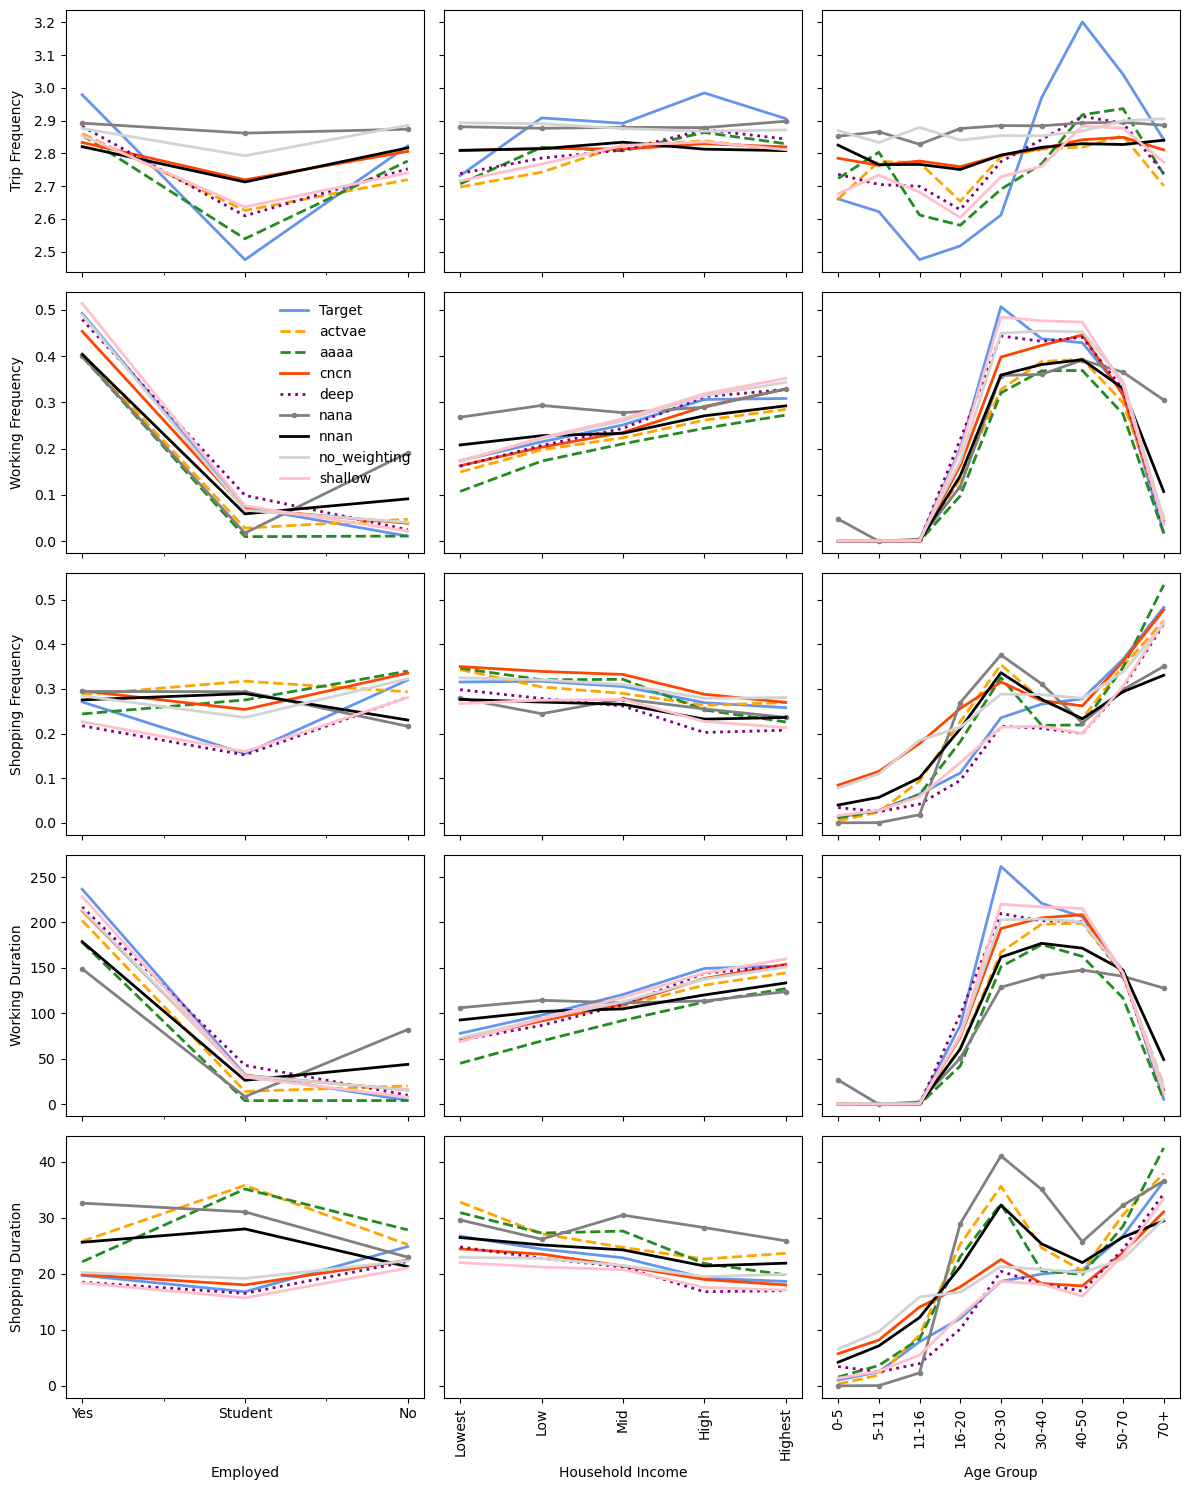

In [29]:
plot_conditionals(
    structure_schedules,
    structure_attributes,
    target_schedules,
    target_attributes,
    figsize=(12, 15),
)

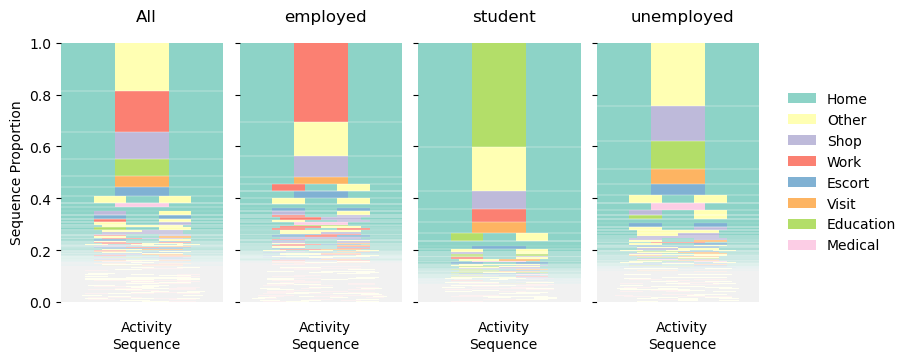

In [30]:
splits = split_on(target_schedules, target_attributes)
fig = describe_transitions.sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
)

actvae
aaaa
cncn
deep
nana
nnan
no_weighting
shallow


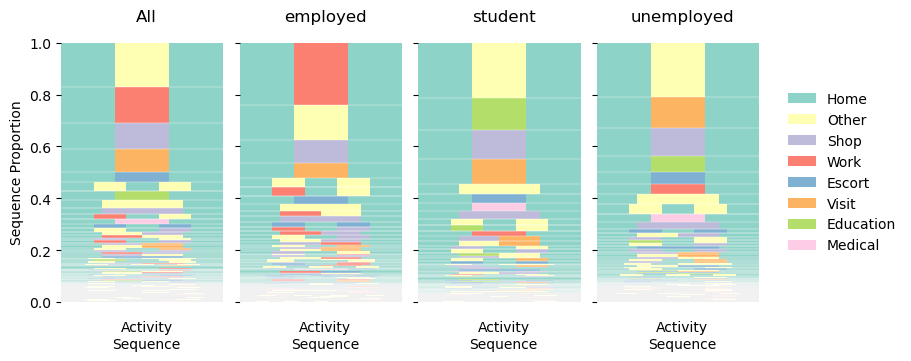

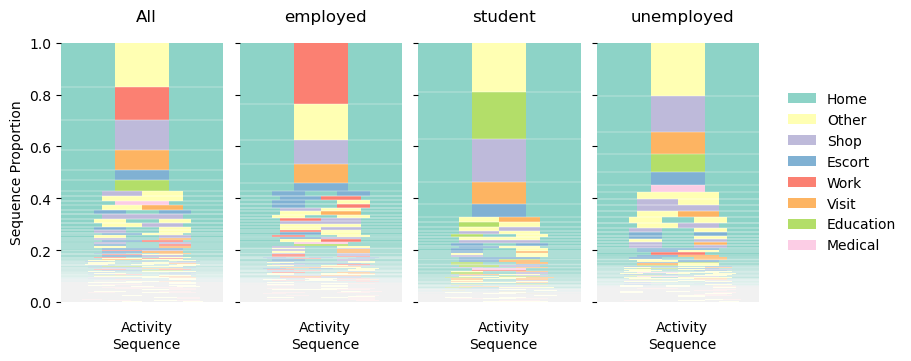

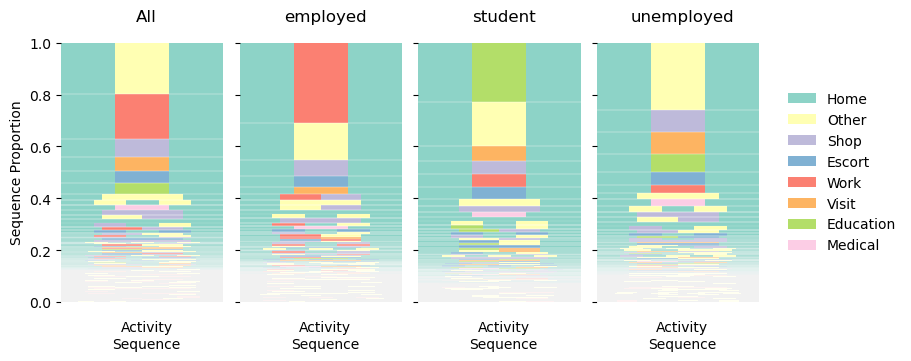

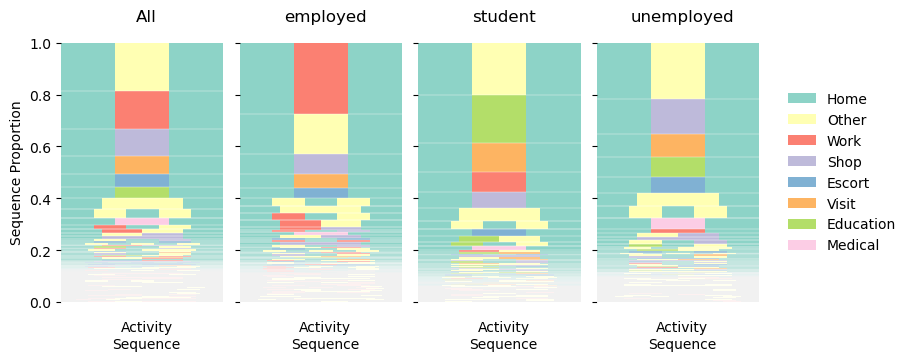

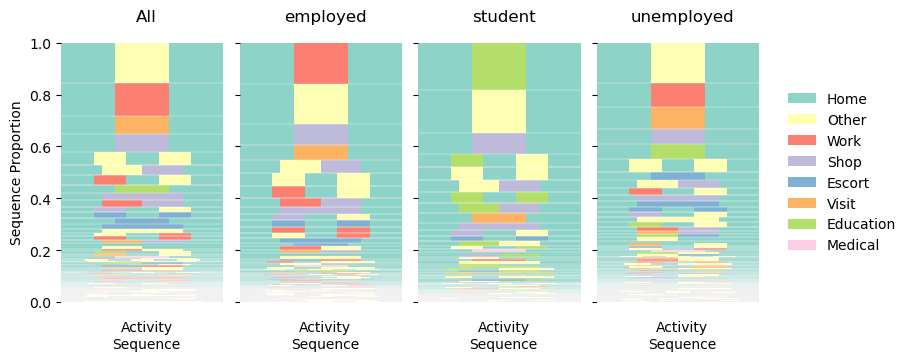

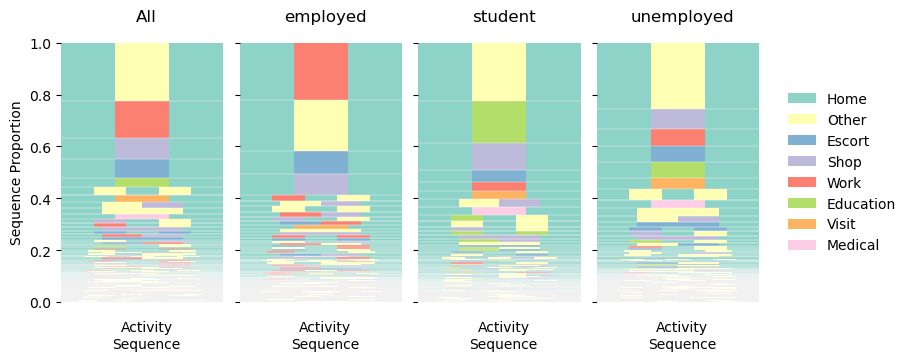

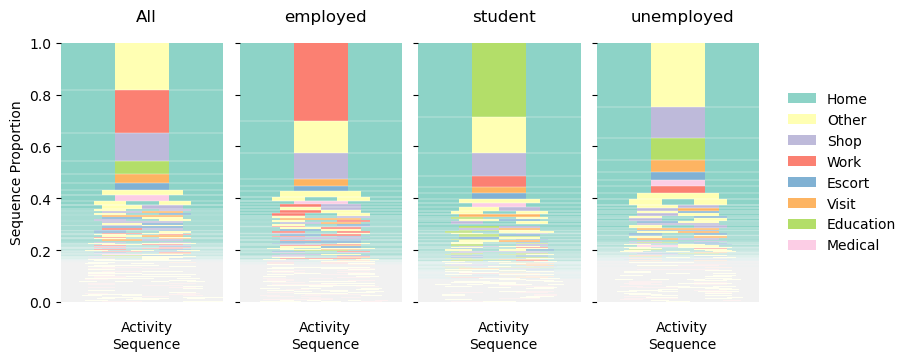

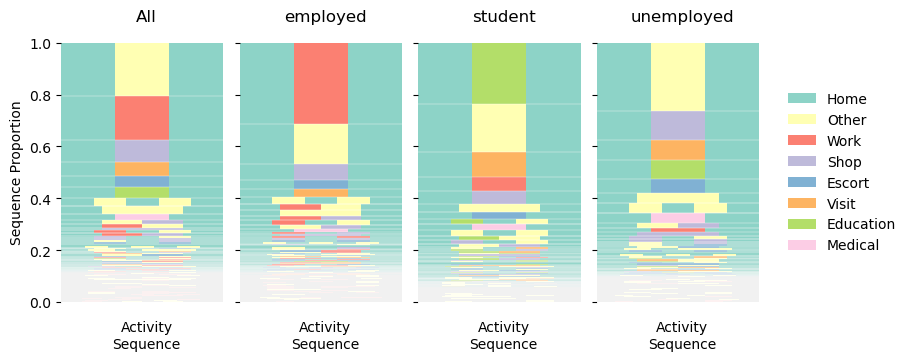

In [31]:
for k, scheds in structure_schedules.items():
    print(k)
    splits = split_on(scheds, structure_attributes[k])
    fig = describe_transitions.sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
    )

In [103]:
# Ageing Scenario
attributes = {
    2023: pd.read_csv(Path("../tmp/nomis_ages_2023.csv")),
    2030: pd.read_csv(Path("../tmp/nomis_ages_2030.csv")),
    2040: pd.read_csv(Path("../tmp/nomis_ages_2040.csv")),
    2050: pd.read_csv(Path("../tmp/nomis_ages_2050.csv")),
}
demographics = pd.DataFrame(
    {year: a.age_group.value_counts() for year, a in attributes.items()}
).loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
print(demographics.sum(axis=0))
demographics

2023    665724
2030    699305
2040    728662
2050    752774
dtype: int64


,2023,2030,2040,2050
age_group,,,,
<5,34326,33646,34374,34675
5-11,37721,34636,34683,35636
11-16,40014,38047,35112,35843
16-20,39084,41337,36695,36744
20-30,84624,91031,91666,84083
30-40,91600,97774,100502,101176
40-50,82651,92829,100742,103549
50-70,163726,166425,169439,187201
70+,91978,103580,125449,133867


In [104]:
# add zero row at top, i.e:
#     0, 0, 0, 0, 0
new_row = pd.DataFrame({year: 0 for year in demographics.columns}, index=["0"])
demographics = pd.concat([new_row, demographics])
demographics

,2023,2030,2040,2050
0,0,0,0,0
<5,34326,33646,34374,34675
5-11,37721,34636,34683,35636
11-16,40014,38047,35112,35843
16-20,39084,41337,36695,36744
20-30,84624,91031,91666,84083
30-40,91600,97774,100502,101176
40-50,82651,92829,100742,103549
50-70,163726,166425,169439,187201
70+,91978,103580,125449,133867


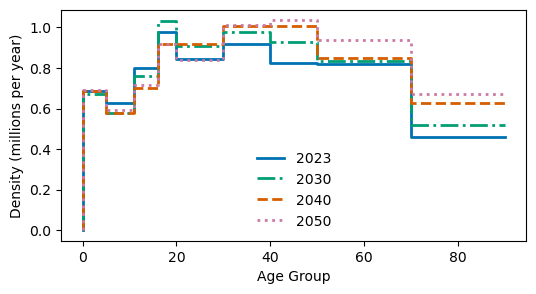

In [118]:
scaled = demographics * 100 / 1000000

scaled["duration"] = [1, 5, 6, 5, 4, 10, 10, 10, 20, 20]
for year in [2023, 2030, 2040, 2050]:
    scaled[year] = scaled[year] / scaled.duration
scaled.duration = scaled.duration.cumsum() - 1

fig, ax = plt.subplots(figsize=(6, 3))

# Use a colorblind-friendly palette from matplotlib
colors = [
    "#0072B2",
    "#009E73",
    "#D55E00",
    "#CC79A7",
]  # blue, green, orange, purple
linestyles = ["-", "-.", "--", ":"]

for year, c, linestyle in zip([2023, 2030, 2040, 2050], colors, linestyles):
    ax.step(
        scaled.duration,
        scaled[year],
        label=str(year),
        color=c,
        linestyle=linestyle,
        linewidth=2,
    )
# for y in scaled.index:
#     ax.axhline(y, color="lightgrey", linestyle="--", linewidth=0.5, zorder=0)

ax.set_ylabel("Density (millions per year)")
ax.set_xlabel("Age Group")
ax.legend(scaled.columns, loc="lower center", frameon=False, title_fontsize=12)
# ax.set_xlim(0, 20)

In [116]:
scaled

,2023,2030,2040,2050,duration
0,0.00000,0.000000,0.000000,0.000000,1
<5,0.68652,0.672920,0.687480,0.693500,6
5-11,0.75442,0.692720,0.693660,0.712720,11
11-16,1.00035,0.951175,0.877800,0.896075,15
16-20,0.97710,1.033425,0.917375,0.918600,19
20-30,0.84624,0.910310,0.916660,0.840830,29
30-40,0.91600,0.977740,1.005020,1.011760,39
40-50,0.82651,0.928290,1.007420,1.035490,49
50-70,0.81863,0.832125,0.847195,0.936005,69
70+,0.45989,0.517900,0.627245,0.669335,89


In [34]:
aged_schedule_paths = {
    n[1:]: Path("../logs/TRB/cvae_nomis_scenario") / n / "version_1"
    for n in ["a2023", "a2030", "a2040", "a2050"]
}
age_schedules = {
    n: pd.read_csv(p / "synthetic_schedules.csv")
    for n, p in aged_schedule_paths.items()
}
age_attributes = {
    n: pd.read_csv(p / "synthetic_attributes.csv")
    for n, p in aged_schedule_paths.items()
}
age_target = age_schedules.pop("2023")
age_attributes_target = age_attributes.pop("2023")

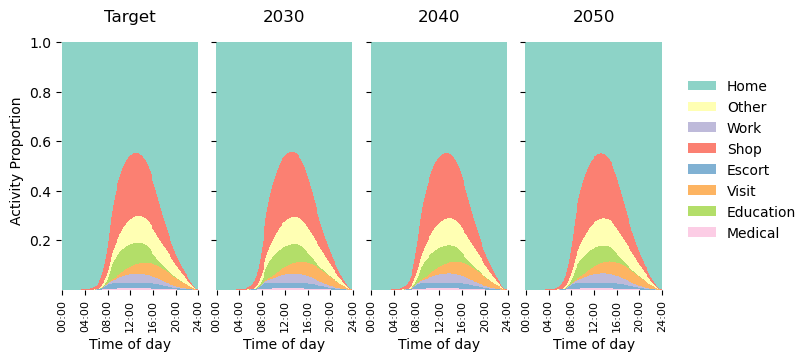

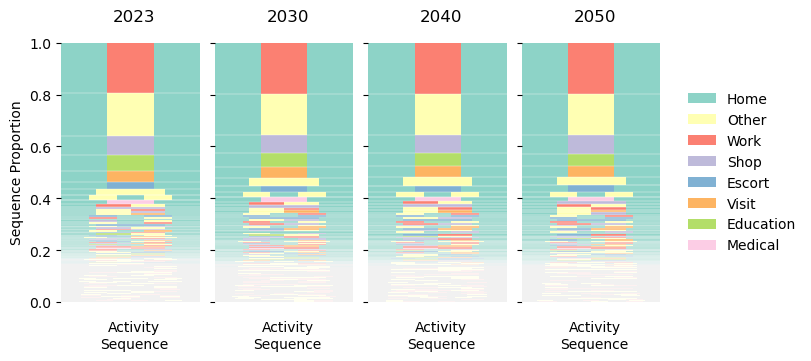

In [35]:
fig = frequency_plots(
    age_target,
    age_schedules,
    color=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    age_target,
    age_schedules,
    cmap=cmap,
    figsize=(8, 3.5),
    observed_title="2023",
)

In [36]:
# for k, scheds in age_schedules.items():
#     splits = split_on(scheds, age_attributes[k], by="age_group")
#     fig = describe_transitions.sequence_prob_plot(
#         scheds, splits, observed_title="All", cmap=cmap, figsize=(16, 3.5)
#     )

In [37]:
aged_scenario = Path(
    "../logs/TRB/cvae_nomis_scenario/label_descriptions_subs.csv"
)
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment", "cat"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations", "participation rate"),
    ["a2023", "a2030", "a2040", "a2050"],
]
aged_scenario = aged_scenario.reset_index()
aged_scenario = aged_scenario.loc[aged_scenario.segment == "education"].drop(
    "segment", axis=1
)
aged_scenario = aged_scenario.set_index("cat")
aged_scenario = aged_scenario.loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
# aged_scenario = aged_scenario.pivot(columns="cat")
aged_scenario

/tmp/ipykernel_3603315/2520245393.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  aged_scenario = aged_scenario.loc[


,a2023,a2030,a2040,a2050
cat,,,,
<5,0.296626,0.272573,0.274248,0.272704
5-11,0.336497,0.311757,0.311392,0.310697
11-16,0.341905,0.307068,0.306419,0.306615
16-20,0.169839,0.152769,0.152964,0.153032
20-30,0.020148,0.021114,0.020869,0.021039
30-40,0.001277,0.000644,0.000637,0.000633
40-50,0.000206,0.000032,0.000030,0.000029
50-70,0.000183,0.000006,0.000006,0.000016
70+,0.000163,0.000039,0.000032,0.000022


In [38]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
aged_scenario

a2023     a2030     a2040     a2050
feature            segment                                                 
lengths            sequence lengths  3.829916  3.850228  3.852674  3.855971
participation rate education         0.067713  0.057142  0.052952  0.051786
                   escort            0.214443  0.220294  0.218849  0.218631
                   home              2.257499  2.251012  2.252013  2.253520
                   medical           0.036185  0.031992  0.032513  0.032756
                   other             0.520932  0.514941  0.515058  0.515087
                   shop              0.292452  0.313400  0.318673  0.321209
                   visit             0.177148  0.195976  0.196464  0.196920
                   work              0.263545  0.265471  0.266152  0.266063

In [39]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
# aged_scenario = aged_scenario.loc["participation rate"]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
for c in ["a2030", "a2040", "a2050"]:
    aged_scenario[c] = aged_scenario[c].astype(float)
    aged_scenario[f"{c}"] = (
        100
        * (aged_scenario[c] - aged_scenario["a2023"])
        / aged_scenario["a2023"]
    )
aged_scenario = aged_scenario.sort_values(by="a2023", ascending=False)
print(
    aged_scenario.to_latex(
        float_format="{:.3f}".format, index=True, label="tab:aged_scenario"
    )
)
aged_scenario

\begin{table}
\label{tab:aged_scenario}
\begin{tabular}{llrrrr}
\toprule
 &  & a2023 & a2030 & a2040 & a2050 \\
feature & segment &  &  &  &  \\
\midrule
lengths & sequence lengths & 3.830 & 0.530 & 0.594 & 0.680 \\
\cline{1-6}
\multirow[t]{8}{*}{participation rate} & home & 2.257 & -0.287 & -0.243 & -0.176 \\
 & other & 0.521 & -1.150 & -1.128 & -1.122 \\
 & shop & 0.292 & 7.163 & 8.966 & 9.833 \\
 & work & 0.264 & 0.731 & 0.989 & 0.955 \\
 & escort & 0.214 & 2.729 & 2.055 & 1.953 \\
 & visit & 0.177 & 10.628 & 10.904 & 11.161 \\
 & education & 0.068 & -15.610 & -21.799 & -23.521 \\
 & medical & 0.036 & -11.588 & -10.147 & -9.475 \\
\cline{1-6}
\bottomrule
\end{tabular}
\end{table}



a2023      a2030      a2040      a2050
feature            segment                                                    
lengths            sequence lengths  3.829916   0.530363   0.594212   0.680312
participation rate home              2.257499  -0.287332  -0.243013  -0.176255
                   other             0.520932  -1.150022  -1.127664  -1.122072
                   shop              0.292452   7.162967   8.966137   9.833343
                   work              0.263545   0.730831   0.989417   0.955412
                   escort            0.214443   2.728560   2.054551   1.953026
                   visit             0.177148  10.628099  10.903687  11.160791
                   education         0.067713 -15.610499 -21.799289 -23.521348
                   medical           0.036185 -11.587510 -10.146973  -9.474969

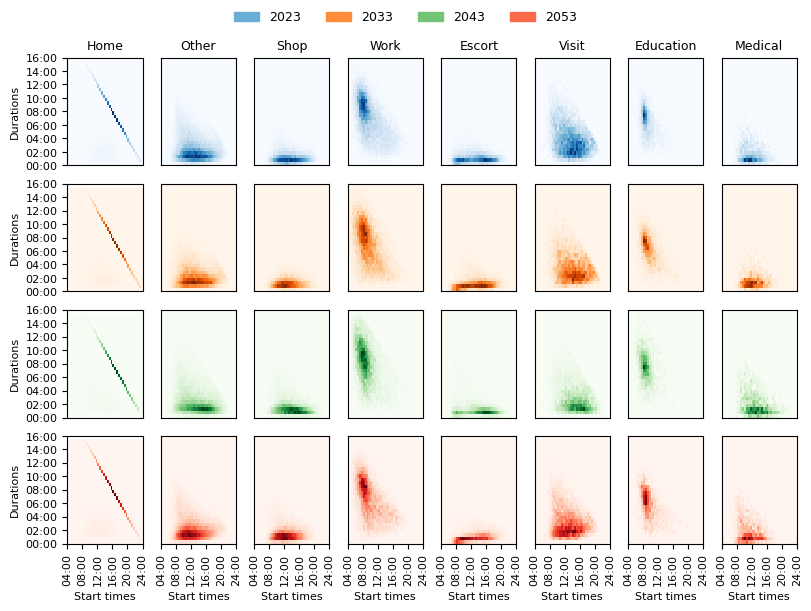

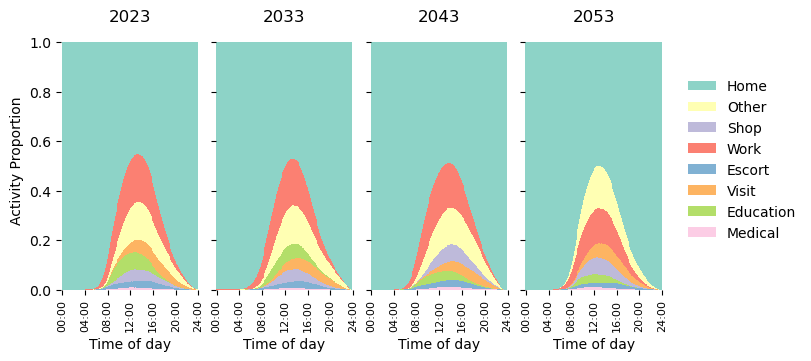

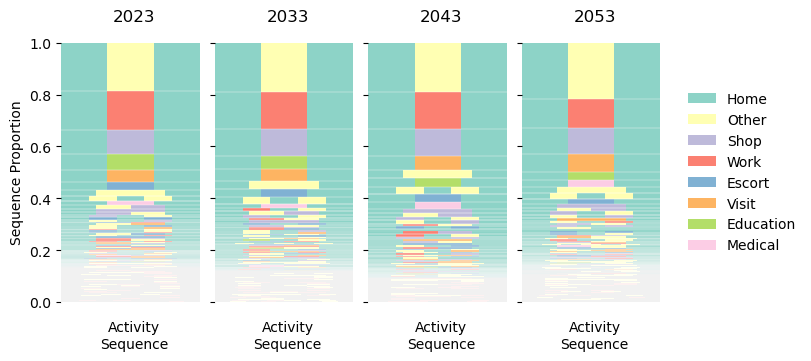

In [40]:
schedules = {
    year: pd.read_csv(
        latest(Path("../logs/TRB/cvae_ageing_scenario") / f"a{year}")[1]
        / "synthetic_schedules.csv"
    )
    for year in ["2023", "2033", "2043", "2053"]
}

base = schedules.pop("2023")

fig = joint_time_distributions_plot(
    base,
    schedules,
    figsize=(8, 6),
    observed_title="2023",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)
fig = frequency_plots(
    base, schedules, color=cmap, figsize=(8, 3.5), observed_title="2023"
)
fig = describe_transitions.sequence_prob_plot(
    base, schedules, observed_title="2023", cmap=cmap, figsize=(8, 3.5)
)

In [41]:
sample_scenario = Path(
    "../logs/TRB/cvae_sampled_scenario/domain_distances_subs.csv"
)
sample_scenario = (
    pd.read_csv(sample_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    sample_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["s200", "s100", "s50", "s25", "s12"],
    ].to_latex(float_format="{:.3f}".format)
)

\begin{tabular}{lrrrrr}
\toprule
 & s200 & s100 & s50 & s25 & s12 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.084 & 0.080 & 0.089 & 0.151 & 0.197 \\
transitions & 0.008 & 0.008 & 0.010 & 0.010 & 0.021 \\
timing & 0.030 & 0.030 & 0.039 & 0.049 & 0.068 \\
feasibility & 0.011 & 0.010 & 0.022 & 0.040 & 0.108 \\
creativity & 0.008 & 0.005 & 0.002 & 0.002 & 0.002 \\
\bottomrule
\end{tabular}



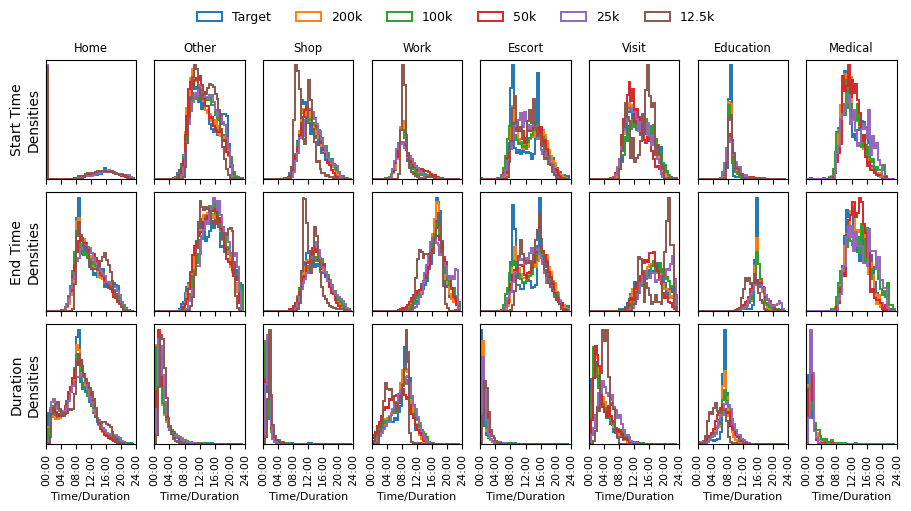

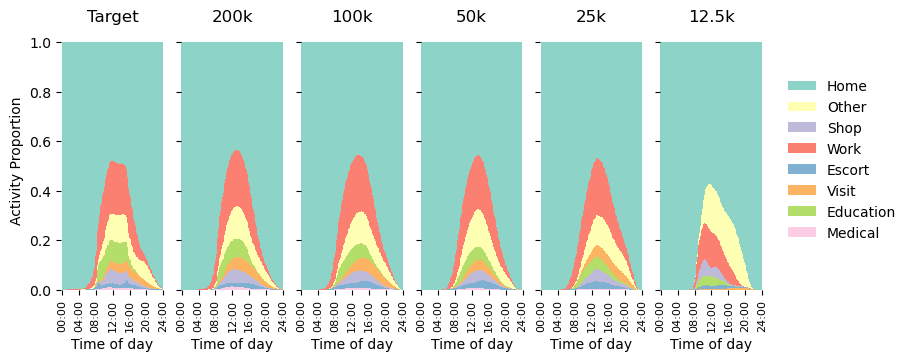

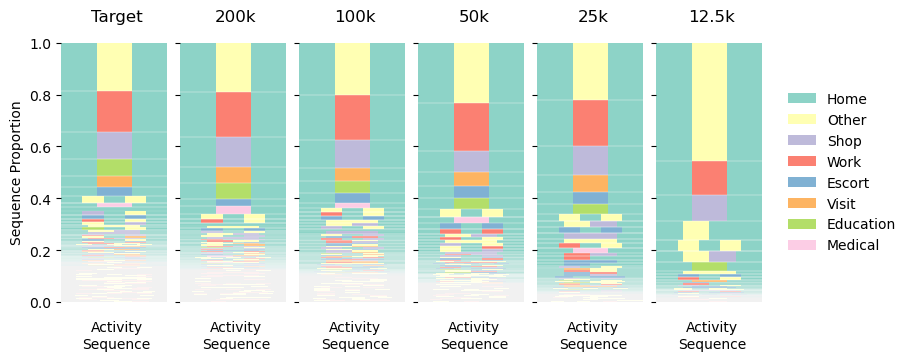

In [42]:
s200 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s200"))[1]
    / "synthetic_schedules.csv"
)
s100 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s100"))[1]
    / "synthetic_schedules.csv"
)

s50 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s50"))[1]
    / "synthetic_schedules.csv"
)
s25 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s25"))[1]
    / "synthetic_schedules.csv"
)
s12 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s12"))[1]
    / "synthetic_schedules.csv"
)
# s6 = pd.read_csv(
#     latest(Path("../logs/TRB/cvae_sampled_scenario/s6"))[1]
#     / "synthetic_schedules.csv"
# )

sampled_schedules = {
    "200k": s200,
    "100k": s100,
    "50k": s50,
    "25k": s25,
    "12.5k": s12,
}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmap,
    figsize=(9, 3.5),
)

In [43]:
# # labels scenario
label_scenario = Path("../logs/TRB/cvae_labels_scenario/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8", "l16"]]

\begin{tabular}{lrrrrr}
\toprule
 & l1 & l2 & l4 & l8 & l16 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.054 & 0.057 & 0.057 & 0.082 & 0.095 \\
transitions & 0.003 & 0.005 & 0.003 & 0.005 & 0.003 \\
timing & 0.024 & 0.026 & 0.031 & 0.030 & 0.034 \\
feasibility & 0.014 & 0.037 & 0.032 & 0.024 & 0.009 \\
creativity & 0.024 & 0.024 & 0.021 & 0.017 & 0.017 \\
\bottomrule
\end{tabular}



,l1,l2,l4,l8,l16
domain,,,,,
creativity,0.024435,0.023776,0.020766,0.016546,0.017022
feasibility,0.014142,0.036758,0.032240,0.024471,0.008671
participations,0.053846,0.056799,0.056863,0.082038,0.095341
timing,0.024288,0.026039,0.030703,0.030038,0.033583
transitions,0.003493,0.005311,0.003229,0.005120,0.003324


In [44]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/domain_distances_subs.csv"
)
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8"]]

\begin{tabular}{lrrrrr}
\toprule
 & l1 & l2 & l4 & l8 & l16 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.060 & 0.066 & 0.061 & 0.083 & 0.105 \\
transitions & 0.005 & 0.006 & 0.004 & 0.006 & 0.005 \\
timing & 0.026 & 0.029 & 0.032 & 0.032 & 0.035 \\
feasibility & 0.014 & 0.037 & 0.032 & 0.024 & 0.009 \\
creativity & 0.021 & 0.020 & 0.016 & 0.013 & 0.012 \\
\bottomrule
\end{tabular}



,l1,l2,l4,l8
domain,,,,
creativity,0.020729,0.019912,0.015650,0.012537
feasibility,0.014095,0.036662,0.032117,0.024398
participations,0.059690,0.065520,0.060706,0.083230
timing,0.026470,0.028956,0.032429,0.031748
transitions,0.004730,0.006452,0.004123,0.005961


In [45]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/label_descriptions_subs.csv"
)
label_scenario = pd.read_csv(label_scenario)
label_scenario = label_scenario.loc[
    label_scenario.cat.isin(["employed", "unemployed"])
]
label_scenario = label_scenario.set_index(
    ["domain", "feature", "segment", "label", "cat"]
).drop("unit", axis=1)


def aggregate_label_scenario(label_scenario):
    agg = {}
    for c in ["observed", "l1", "l2", "l4", "l8"]:
        agg[c] = (
            label_scenario[c] * label_scenario[f"{c}__weight"]
        ).sum() / label_scenario[f"{c}__weight"].sum()
    return pd.Series(agg)


label_scenario.groupby(["domain", "cat"]).apply(aggregate_label_scenario)

observed        l1        l2        l4        l8
domain         cat                                                         
creativity     employed    0.856972  0.983364  0.983169  0.985587  0.988441
               unemployed  0.828239  0.973999  0.975970  0.982296  0.985900
feasibility    employed    0.000000  0.005289  0.013351  0.016302  0.010590
               unemployed  0.000000  0.005360  0.014716  0.007735  0.007757
participations employed    0.210674  0.203601  0.201544  0.204747  0.201680
               unemployed  0.202714  0.197887  0.202357  0.197503  0.200837
timing         employed    0.453887  0.462139  0.460808  0.462901  0.462213
               unemployed  0.447872  0.458653  0.452141  0.458111  0.453287
transitions    employed    0.007494  0.012631  0.018294  0.013983  0.013391
               unemployed  0.008813  0.012343  0.018709  0.013162  0.013693

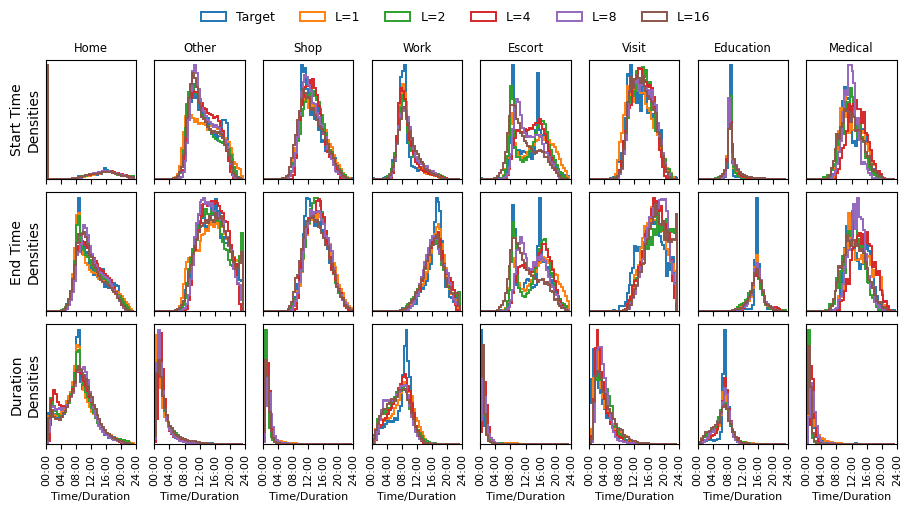

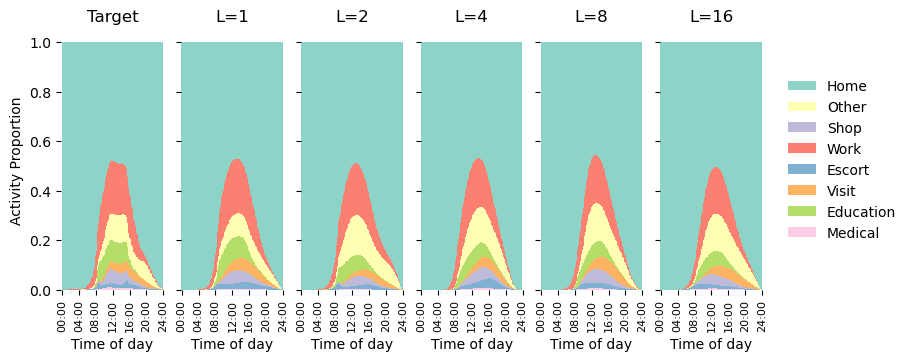

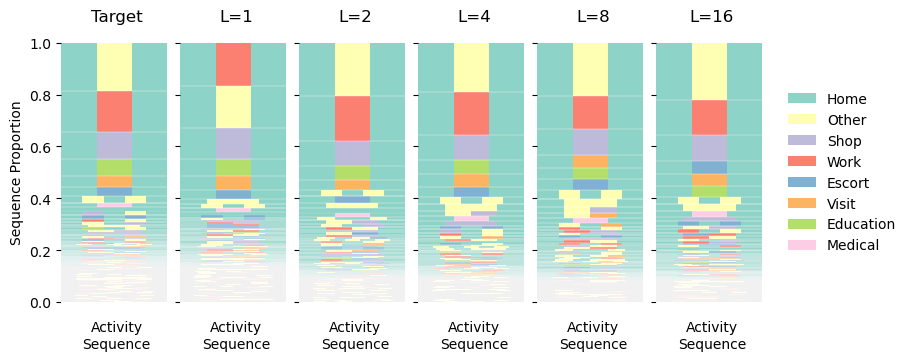

In [46]:
l1 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l1"))[1]
    / "synthetic_schedules.csv"
)

l2 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l2"))[1]
    / "synthetic_schedules.csv"
)
l4 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l4"))[1]
    / "synthetic_schedules.csv"
)
l8 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l8"))[1]
    / "synthetic_schedules.csv"
)
l16 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l16"))[1]
    / "synthetic_schedules.csv"
)

sampled_schedules = {"L=1": l1, "L=2": l2, "L=4": l4, "L=8": l8, "L=16": l16}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmap,
    figsize=(9, 3.5),
)

In [47]:
# transfer scenario
label_scenario = Path("../logs/TRB/cvae_transfer_scenario/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["1yr_base", "transfer"],
    ].to_latex(float_format="{:.3f}".format)
)

label_scenario = Path(
    "../logs/TRB/cvae_transfer_scenario/domain_distances_subs.csv"
)
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["1yr_base", "transfer"],
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario

\begin{tabular}{lrr}
\toprule
 & 1yr_base & transfer \\
domain &  &  \\
\midrule
participations & 0.063 & 0.055 \\
transitions & 0.004 & 0.002 \\
timing & 0.026 & 0.017 \\
feasibility & 0.026 & 0.011 \\
creativity & 0.016 & 0.025 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrr}
\toprule
 & 1yr_base & transfer \\
domain &  &  \\
\midrule
participations & 0.070 & 0.071 \\
transitions & 0.005 & 0.003 \\
timing & 0.028 & 0.020 \\
feasibility & 0.026 & 0.011 \\
creativity & 0.009 & 0.016 \\
\bottomrule
\end{tabular}



,transfer,1yr_base
domain,,
creativity,0.016186,0.009343
feasibility,0.011280,0.026231
participations,0.071152,0.069875
timing,0.020033,0.027567
transitions,0.003486,0.004992


In [48]:
for n in ["aggregate", "participations", "transitions", "timing"]:
    print(n)
    print(table.loc[n].to_latex(float_format="{:.3f}".format))
    print()

aggregate


KeyError: 'aggregate'

In [ ]:
def build_creativity_table(batch_paths):
    descriptions_combined = pd.DataFrame()
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = (
            pd.read_csv(path / "descriptions.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )
        distances = (
            pd.read_csv(path / "distances.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
            - weights
        )

        descriptions_combined[name, "desc."] = descriptions[columns].mean(
            axis=1
        )

        distances_combined[name, "dist."] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["description"]

    print(descriptions_combined.columns)

    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    distances_combined["Observed", ""] = distances["observed"]
    distances_combined["Description", ""] = distances["distance"]

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    descriptions_combined = descriptions_combined.loc[:, order]

    order = list(distances_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    distances_combined = distances_combined.loc[:, order]

    return pd.concat((descriptions_combined, distances_combined), axis=0)


table = build_creativity_table(batch_paths)
table

In [ ]:
print(table.loc["sample quality"].to_latex(float_format="{:.3f}".format))
table.loc["sample quality"]

In [ ]:
table.loc["creativity"]

In [ ]:
print(table.to_latex(float_format="{:.3f}".format))

In [ ]:
for domain in [
    "creativity",
    "sample quality",
    "aggregate",
    "participations",
    "transitions",
    "timing",
]:
    print()
    print(domain)
    print()
    ss = table.loc[domain]
    for feature in set(ss.reset_index()["feature"]):
        print(feature)
        print()
        print(ss.loc[feature].to_latex(float_format="{:.3f}".format))

In [ ]:
def build_subs_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions_subs.csv").set_index(
            ["domain", "feature", "segment", "sub_pop"]
        )
        columns = set(descriptions.columns)
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
        )

        descriptions_combined[name] = descriptions[columns].mean(axis=1)

    descriptions_combined["Observed"] = descriptions["observed"]
    descriptions_combined["Description"] = descriptions["description"]

    descriptions_combined = (
        descriptions_combined.sort_values("Observed", ascending=False)
        .groupby(["domain", "feature", "sub_pop"])
        .head(100)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index("Observed"))
    order = ["Observed"] + order

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return descriptions_combined.loc[index, order]


table = build_subs_description_tables(batch_paths)
table

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "work0",
    ["work_status=student", "work_status=employed"],
]

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "education0",
    ["work_status=student", "work_status=employed"],
]